## Installing packages

In [1]:
%pip install tsfresh

  Using cached tsfresh-0.21.1-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached statsmodels-0.14.5-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached pywavelets-1.8.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.0 kB)
  Using cached stumpy-1.13.0-py3-none-any.whl.metadata (28 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached charset_normalizer-3.4.4-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached numba-0.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.45.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
Using cache

In [2]:
%pip install xgboost

  Using cached xgboost-3.1.1-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.1-py3-none-manylinux_2_28_x86_64.whl (115.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install optuna

  Using cached optuna-4.6.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.17.1-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.44-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.5 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached tomli-2.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached greenlet-3.2.4-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (4.1 kB)
Using cached optuna-4.6.0-py3-none-any.whl (404 kB)
Using cached alembic-1.17.1-py3-none-any.whl (247 kB)
Using cached sqlalchemy-2.0.44-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.2 MB)
Using cached greenlet-3.2.4-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (584 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)
Using cached tomli-2.3.0-py3-none-any.whl (14 kB)
   ━━━━━━━━

In [4]:
%pip list

Package                  Version
------------------------ -----------
aiohappyeyeballs         2.6.1
aiohttp                  3.13.2
aiosignal                1.4.0
albucore                 0.0.24
albumentations           2.0.8
alembic                  1.17.1
annotated-types          0.7.0
asttokens                3.0.0
async-timeout            5.0.1
attrs                    25.4.0
certifi                  2025.11.12
charset-normalizer       3.4.4
cloudpickle              3.1.2
colorlog                 6.10.1
comm                     0.2.3
contourpy                1.3.2
cycler                   0.12.1
debugpy                  1.8.17
decorator                5.2.1
exceptiongroup           1.3.0
executing                2.2.1
filelock                 3.20.0
fonttools                4.60.1
frozenlist               1.8.0
fsspec                   2025.10.0
greenlet                 3.2.4
idna                     3.11
ImageIO                  2.37.2
ipykernel                7.1.0
ipython      

In [7]:
import pandas as pd
import numpy as np
from tsfresh import extract_features
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.feature_extraction.feature_calculators import mean
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import optuna
# import kan 
# import pykan
# from kan import KAN
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from tsfresh.feature_extraction import ComprehensiveFCParameters

# Time Series Feature Extraction based on scalable hypothesis tests

here we use TSFresh :)

- Statistical Rigor: The library applies statistical hypothesis tests to determine feature relevance, ensuring the selected features are statistically significant and less prone to overfitting.
- Scalability: tsfresh is designed to handle large datasets efficiently (multiple time series: RMN)

In [3]:
### raw_data

dataset_path = 'data_train.csv'
df = pd.read_csv(dataset_path, sep="\t").iloc[:, list(range(700)) + [-1]]
df.shape

test = pd.read_csv('data_test.csv', sep="\t").iloc[:, list(range(700))]
print(df.shape , test.shape)

(1000, 701) (1000, 700)


In [34]:
test

,0,1,2,3,4,5,6,7,8,9,...,690,691,692,693,694,695,696,697,698,699
0,0.788302,0.833668,0.777146,0.819389,0.861003,0.807070,0.821894,0.811667,0.827137,0.796143,...,0.000000,0.044756,0.000000,0.000000,0.068068,0.020412,0.053027,0.035331,0.018462,0.100288
1,0.884277,0.864711,0.746354,0.786617,0.749206,0.736673,0.753945,0.791456,0.732960,0.744620,...,0.000000,0.000000,0.000000,0.000000,0.041023,0.053772,0.000000,0.043722,0.046076,0.023762
2,0.899784,0.774386,0.864490,0.895171,0.822695,0.785098,0.814283,0.804869,0.853816,0.828943,...,0.010084,0.000000,0.000000,0.001536,0.005383,0.000000,0.088467,0.004206,0.008769,0.049756
3,0.872215,0.913709,0.742457,0.813629,0.796481,0.763009,0.777455,0.696683,0.719256,0.806203,...,0.022901,0.079691,0.000000,0.000000,0.000000,0.055817,0.043545,0.000000,0.000000,0.000000
4,0.849244,0.797369,0.818437,0.764594,0.704282,0.759954,0.744396,0.750625,0.772093,0.712152,...,0.015463,0.051818,0.130450,0.000000,0.000000,0.000000,0.000000,0.023519,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.825135,0.906567,0.823369,0.802071,0.890256,0.875190,0.804806,0.784156,0.792596,0.789138,...,0.000000,0.000000,0.000000,0.005588,0.070841,0.000000,0.000000,0.014943,0.075857,0.001993
996,0.851421,0.871547,0.856086,0.793908,0.768383,0.724346,0.717519,0.731956,0.813253,0.761697,...,0.000000,0.000000,0.000000,0.007355,0.000000,0.000000,0.028962,0.000000,0.000000,0.000000
997,0.924303,0.849955,0.905681,0.789871,0.823404,0.858669,0.795157,0.730247,0.719397,0.791538,...,0.011307,0.001566,0.057423,0.010473,0.000000,0.047478,0.000000,0.000000,0.069526,0.040456
998,0.871070,0.831418,0.888724,0.844934,0.819290,0.826558,0.804389,0.707092,0.745585,0.763603,...,0.106195,0.050221,0.000000,0.006570,0.070200,0.064989,0.000000,0.009210,0.009249,0.039728


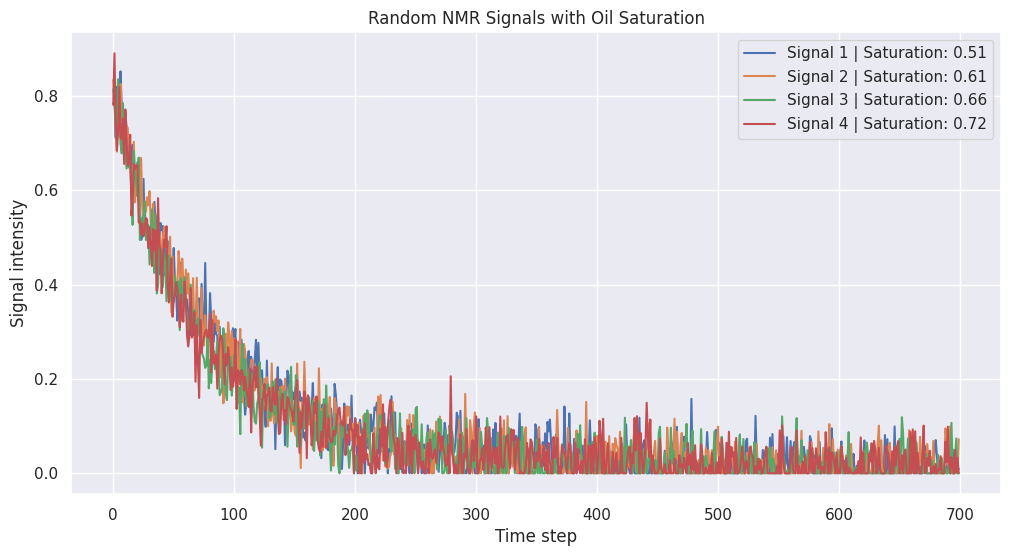

In [67]:
# Randomly select 5 samples
samples = df.sample(4, random_state=42)

# Create the plot
plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(samples.iterrows()):
    signal = row.iloc[:-1].values  # all signal columns
    y = row.iloc[-1]               # target value (saturation)
    
    plt.plot(signal, label=f'Signal {i+1} | Saturation: {y:.2f}')

plt.title("Random NMR Signals with Oil Saturation")
plt.xlabel("Time step")
plt.ylabel("Signal intensity")
plt.legend()
plt.grid(True)
plt.show()

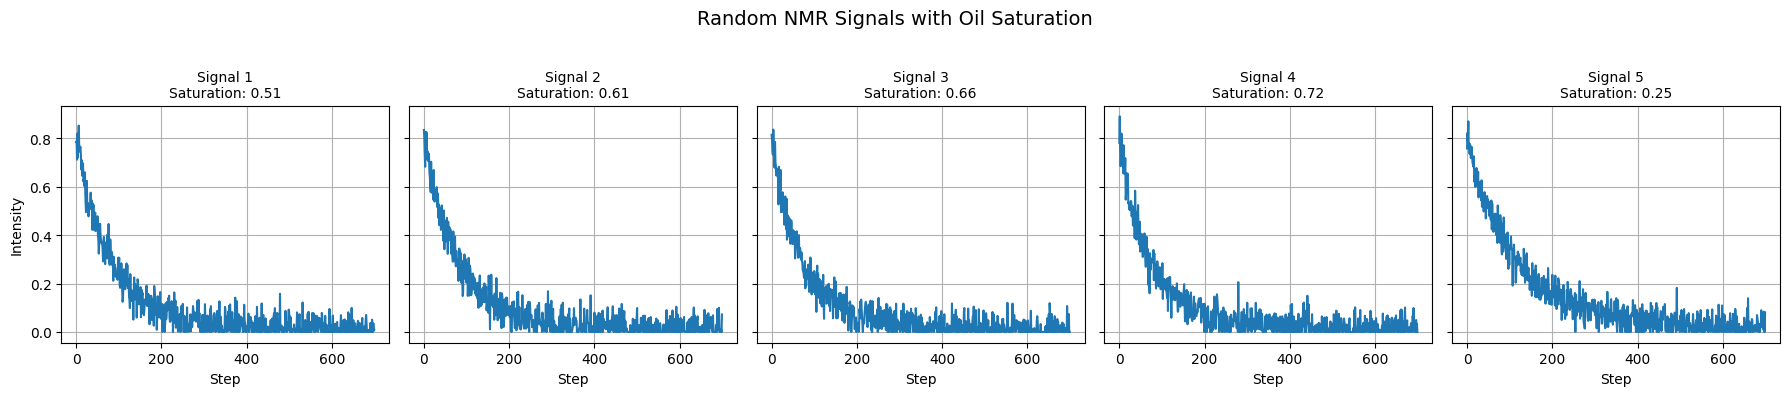

In [4]:
samples = df.sample(5, random_state=42)

# Create 5 subplots in one row
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for i, (ax, (_, row)) in enumerate(zip(axes, samples.iterrows())):
    signal = row.iloc[:-1].values  # signal columns
    y = row.iloc[-1]               # target (saturation)
    
    ax.plot(signal, color='tab:blue')
    ax.set_title(f'Signal {i+1}\nSaturation: {y:.2f}', fontsize=10)
    ax.set_xlabel("Step")
    ax.grid(True)

axes[0].set_ylabel("Intensity")

plt.suptitle("Random NMR Signals with Oil Saturation", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

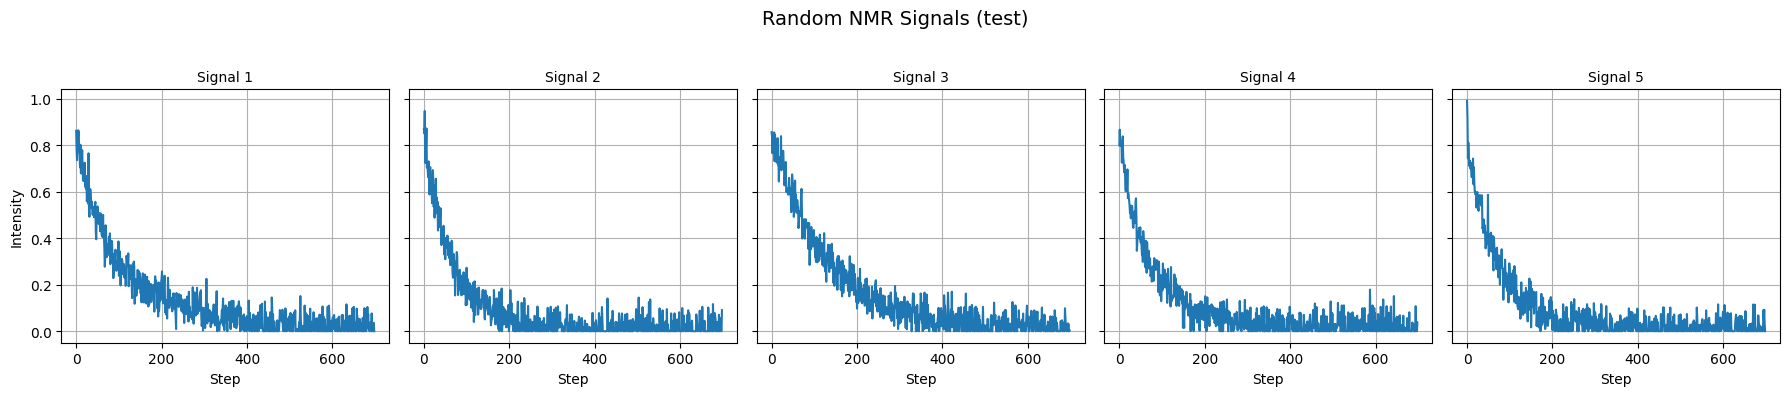

In [5]:
# Randomly select 5 samples
samples = test.sample(5, random_state=0)

# Create 5 subplots in one row
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for i, (ax, (_, row)) in enumerate(zip(axes, samples.iterrows())):
    signal = row.iloc[:-1].values  # signal columns    
    ax.plot(signal, color='tab:blue')
    ax.set_title(f'Signal {i+1}', fontsize=10)
    ax.set_xlabel("Step")
    ax.grid(True)

axes[0].set_ylabel("Intensity")

plt.suptitle("Random NMR Signals (test)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# TSFresh (2200)

In [53]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,2192,2193,2194,2195,2196,2197,2198,2199,2200,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.801440,0.788660,0.778124,0.768065,0.761123,0.750199,0.739833,0.730254,0.722810,0.712503,...,0.017270,0.017598,0.016942,0.016991,0.018045,0.018382,0.016829,0.018097,0.017313,0.397510
std,0.045031,0.043412,0.046033,0.047485,0.046102,0.047706,0.046673,0.047268,0.048707,0.046526,...,0.026170,0.025671,0.025678,0.025000,0.026961,0.026011,0.025378,0.026247,0.025341,0.229629
min,0.657811,0.623109,0.633672,0.596000,0.581854,0.609262,0.607392,0.577199,0.576855,0.572337,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.771315,0.759520,0.746926,0.737416,0.731369,0.718673,0.709493,0.699165,0.690767,0.682058,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210000
50%,0.803054,0.789231,0.779266,0.769701,0.761062,0.747896,0.740497,0.729602,0.723894,0.713736,...,0.000000,0.000000,0.000000,0.000293,0.000000,0.002630,0.000000,0.001502,0.000621,0.390000
75%,0.831890,0.818317,0.809860,0.799344,0.793397,0.780805,0.769862,0.762076,0.753891,0.744148,...,0.029219,0.029338,0.027938,0.028825,0.031366,0.032523,0.029696,0.031561,0.029341,0.600000
max,0.956774,0.906670,0.904843,0.930188,0.902695,0.938701,0.885892,0.914277,0.873082,0.872444,...,0.133491,0.120664,0.127643,0.149430,0.177943,0.147093,0.120986,0.156544,0.162247,0.800000


In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,2192,2193,2194,2195,2196,2197,2198,2199,2200,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.955225,0.940321,0.927828,0.915889,0.907654,0.894609,0.882408,0.871052,0.862157,0.849803,...,0.020569,0.020995,0.020238,0.020278,0.021589,0.021979,0.020072,0.021555,0.020646,0.397510
std,0.048000,0.052309,0.056686,0.059090,0.058461,0.059552,0.060929,0.062393,0.063750,0.060458,...,0.031169,0.030626,0.030683,0.029885,0.032295,0.031169,0.030297,0.031284,0.030245,0.229629
min,0.774094,0.740656,0.758007,0.676600,0.719316,0.690683,0.673207,0.673429,0.672202,0.682939,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.925207,0.904011,0.886147,0.875599,0.864737,0.854669,0.841474,0.830381,0.819510,0.811549,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210000
50%,0.967288,0.947921,0.932400,0.919783,0.909100,0.893727,0.884265,0.872295,0.862971,0.849886,...,0.000000,0.000000,0.000000,0.000350,0.000000,0.003067,0.000000,0.001769,0.000744,0.390000
75%,1.000000,0.989090,0.976260,0.962918,0.951886,0.936999,0.925713,0.912883,0.904443,0.891234,...,0.034847,0.035021,0.033117,0.034731,0.037997,0.039364,0.035822,0.037114,0.034867,0.600000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.159386,0.144123,0.156254,0.180804,0.210711,0.181184,0.147625,0.195900,0.193323,0.800000


In [ ]:
### Basico: plot de describe()

<Axes: xlabel='index', ylabel='std'>

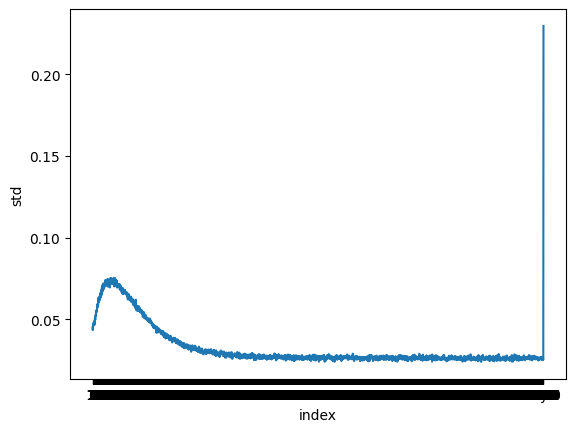

In [54]:
desc = df.describe().T.reset_index()
# desc['index'] = pd.to_numeric(desc['index'], errors='coerce')
sns.lineplot(data=desc, x='index', y='std')

<Axes: xlabel='index', ylabel='mean'>

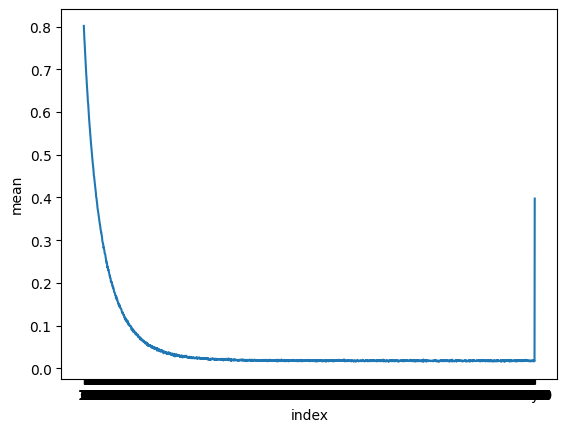

In [55]:
sns.lineplot(data=desc, x='index', y='mean')

<Axes: xlabel='mean', ylabel='std'>

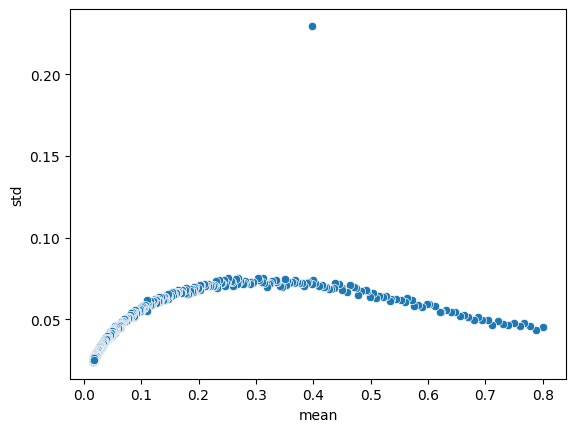

In [57]:
sns.scatterplot(data=desc, x='mean', y='std')

### Convert to TSFresh input

In [56]:
X = df.drop(columns=['y'])
y = df['y']

# converter wide -> long format (TSFresh input)
df_long = X.copy()
df_long['id'] = df_long.index

df_long = df_long.melt(
    id_vars='id',
    var_name='time',
    value_name='value'
)

df_long

,id,time,value
0,0,0,0.808799
1,1,0,0.806849
2,2,0,0.730200
3,3,0,0.821097
4,4,0,0.735200
...,...,...,...
2200995,995,2200,0.023821
2200996,996,2200,0.000000
2200997,997,2200,0.025699
2200998,998,2200,0.013295


### Extracing features

**Choose the feature set:**

MinimalFCParameters() → fast, stable

EfficientFCParameters() → richer

ComprehensiveFCParameters() → huge and slow

In [10]:
extracted_features = extract_features(
    df_long,
    column_id="id",
    column_sort="time",
    default_fc_parameters=EfficientFCParameters(),  # or EfficientFCParameters()
    impute_function=None
)

Feature Extraction: 100%|██████████| 334/334 [02:24<00:00,  2.31it/s]


In [79]:
extracted_features

NameError: name 'extracted_features' is not defined

In [11]:
from tsfresh.utilities.dataframe_functions import impute

extracted_features = impute(extracted_features)

/opt/venvs/torch/lib/python3.10/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['value__friedrich_coefficients__coeff_0__m_3__r_30'
 'value__friedrich_coefficients__coeff_1__m_3__r_30'
 'value__friedrich_coefficients__coeff_2__m_3__r_30'
 'value__friedrich_coefficients__coeff_3__m_3__r_30'
 'value__max_langevin_fixed_point__m_3__r_30'
 'value__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [12]:
extracted_features

,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,value__median,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.0,1.0,1.0,150.202849,54.102069,0.098402,-0.000455,0.000012,0.017935,...,0.379592,0.558221,2.179669,1.722409,2.990434,4.408229,5.793285,6.837503,0.0,0.964089
1,0.0,0.0,1.0,1.0,148.359617,54.695848,0.096040,-0.000423,0.000024,0.015239,...,0.357079,0.549572,2.204764,1.704137,2.950810,4.335432,5.677204,6.719775,0.0,0.971076
2,0.0,0.0,1.0,1.0,156.886937,56.515160,0.100909,-0.000400,-0.000020,0.021238,...,0.379592,0.547475,2.076650,1.732081,3.021315,4.447174,5.851381,6.900478,0.0,0.933108
3,0.0,0.0,1.0,1.0,116.977753,37.005648,0.079209,-0.000396,0.000043,0.012323,...,0.400927,0.581697,2.380779,1.712620,2.956625,4.318556,5.661957,6.706212,0.0,0.925208
4,0.0,0.0,1.0,1.0,109.824450,33.061793,0.071303,-0.000371,-0.000020,0.011854,...,0.357079,0.560855,2.353061,1.693777,2.908714,4.274825,5.606053,6.641011,0.0,0.880543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,1.0,1.0,139.950581,47.225310,0.091075,-0.000380,-0.000031,0.016589,...,0.379592,0.558221,2.273362,1.717426,2.989431,4.378507,5.747799,6.799302,0.0,0.898960
996,0.0,0.0,1.0,1.0,128.046229,42.390478,0.083996,-0.000388,0.000007,0.015031,...,0.379592,0.552067,2.310569,1.713739,2.963276,4.373496,5.771139,6.831978,0.0,0.936746
997,0.0,0.0,1.0,1.0,129.008569,40.010049,0.083148,-0.000455,0.000024,0.014354,...,0.357079,0.595158,2.364823,1.714407,2.954216,4.336936,5.708861,6.744719,0.0,0.890355
998,0.0,0.0,1.0,1.0,119.672418,38.685493,0.078795,-0.000433,-0.000012,0.012162,...,0.379592,0.573048,2.390552,1.706335,2.947534,4.341407,5.704388,6.758872,0.0,0.933590


### Selecionando Features
baseado no target 

In [13]:
from tsfresh import select_features

selected_features = select_features(extracted_features, y)

In [14]:
selected_features

,"value__agg_autocorrelation__f_agg_""var""__maxlag_40",value__kurtosis,value__skewness,value__ratio_beyond_r_sigma__r_1.5,value__lempel_ziv_complexity__bins_5,value__ratio_beyond_r_sigma__r_2,value__lempel_ziv_complexity__bins_3,"value__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""max""",value__ratio_beyond_r_sigma__r_2.5,value__lempel_ziv_complexity__bins_2,...,"value__fft_coefficient__attr_""angle""__coeff_84",value__autocorrelation__lag_2,"value__fft_coefficient__attr_""angle""__coeff_74","value__change_quantiles__f_agg_""mean""__isabs_False__qh_1.0__ql_0.0","value__change_quantiles__f_agg_""mean""__isabs_False__qh_1.0__ql_0.2","value__fft_coefficient__attr_""real""__coeff_86",value__mean_change,"value__fft_coefficient__attr_""real""__coeff_69","value__fft_coefficient__attr_""real""__coeff_57","value__fft_coefficient__attr_""angle""__coeff_89"
0,0.027136,15.344443,3.699521,0.064516,0.093139,0.047706,0.070877,0.270127,0.037256,0.051795,...,-94.464228,0.004890,-38.947448,-0.000455,-0.000455,-2.185269,-0.000455,3.616283,2.598911,-32.824842
1,0.027564,15.606727,3.738659,0.060881,0.087687,0.052703,0.072240,0.266277,0.039527,0.052703,...,-22.594493,-0.003382,-25.665501,-0.000423,-0.000423,-1.212330,-0.000423,0.732944,4.649241,-52.486348
2,0.031556,13.194472,3.485927,0.065425,0.093594,0.054066,0.071786,0.290402,0.043617,0.054066,...,-119.306479,-0.017625,2.377299,-0.000400,-0.000400,2.371623,-0.000400,2.024938,3.540720,-26.102637
3,0.020687,22.265751,4.360557,0.051340,0.074512,0.041799,0.055429,0.193792,0.034984,0.043617,...,-107.525244,-0.002553,-51.556783,-0.000396,-0.000396,2.096422,-0.000396,2.828113,1.745200,-15.233638
4,0.019325,23.690694,4.498539,0.049977,0.071786,0.040891,0.053612,0.180588,0.034075,0.042708,...,-143.535411,-0.001134,-49.950910,-0.000371,-0.000371,-0.585911,-0.000371,4.914692,3.277174,30.077165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.025347,16.140185,3.772223,0.061790,0.086779,0.048160,0.063607,0.252279,0.038619,0.049069,...,59.382482,-0.007052,-0.690027,-0.000380,-0.000380,0.175378,-0.000380,1.067861,1.512779,-5.143551
996,0.023794,19.173884,4.088255,0.056338,0.081781,0.044525,0.059518,0.230399,0.035438,0.046797,...,-35.700821,-0.031018,10.653847,-0.000388,-0.000388,0.235367,-0.000388,1.923052,0.381849,49.253083
997,0.023064,17.571614,3.876513,0.061790,0.085870,0.044071,0.058155,0.236806,0.036347,0.043617,...,-102.261318,0.006745,-8.946237,-0.000455,-0.000455,-2.355916,-0.000455,2.669328,4.102625,-21.091645
998,0.021096,21.580266,4.306552,0.053612,0.077692,0.042708,0.058610,0.203379,0.034984,0.044071,...,-122.227461,-0.004224,-79.947789,-0.000433,-0.000433,1.349140,-0.000433,0.895500,1.457984,-39.627578


In [15]:
selected_features.to_csv("TSFresh_features.csv", index=True)

## Treinando modelos

podemos experimentar qualquer um: XGBoost, RandomForest, CatBoost, regressão linear, MLP

### XGBoost

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    selected_features, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)

# gráfico y_pred x y_true
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### XGBoost: Otimização dos parametros

aqui uso a biblioteca Optuna, que fornece algoritmos de otimização

função de custo: RMSE

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    selected_features, y, test_size=0.3, random_state=42
)

### função objetivo
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse  # Optuna vai minimizar isso

# Rodar o estudo
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Melhores parâmetros:", study.best_params)
print("Melhor RMSE:", study.best_value)

[I 2025-11-11 16:31:26,069] A new study created in memory with name: no-name-e11b3085-5a1d-43af-9056-014f3b96998b
Best trial: 0. Best value: 0.0891182:   2%|▏         | 1/50 [00:03<03:08,  3.84s/it]

[I 2025-11-11 16:31:29,912] Trial 0 finished with value: 0.08911822127590364 and parameters: {'n_estimators': 1190, 'learning_rate': 0.011043969750776884, 'max_depth': 10, 'subsample': 0.6617672556398717, 'colsample_bytree': 0.9513324799919549, 'min_child_weight': 3, 'gamma': 0.09161444106784267}. Best is trial 0 with value: 0.08911822127590364.


Best trial: 0. Best value: 0.0891182:   4%|▍         | 2/50 [00:05<01:54,  2.38s/it]

[I 2025-11-11 16:31:31,265] Trial 1 finished with value: 0.11703162782098475 and parameters: {'n_estimators': 585, 'learning_rate': 0.04686720982117662, 'max_depth': 7, 'subsample': 0.6706196397553844, 'colsample_bytree': 0.514128052336798, 'min_child_weight': 2, 'gamma': 2.0959504603649712}. Best is trial 0 with value: 0.08911822127590364.


Best trial: 0. Best value: 0.0891182:   6%|▌         | 3/50 [00:07<01:44,  2.23s/it]

...

[I 2025-11-11 16:32:42,571] Trial 47 finished with value: 0.10727772066781469 and parameters: {'n_estimators': 528, 'learning_rate': 0.2794057820363272, 'max_depth': 8, 'subsample': 0.5594604940715314, 'colsample_bytree': 0.5965438971126549, 'min_child_weight': 6, 'gamma': 1.2993294410532674}. Best is trial 33 with value: 0.08798861493024088.


Best trial: 33. Best value: 0.0879886:  98%|█████████▊| 49/50 [01:17<00:01,  1.00s/it]

[I 2025-11-11 16:32:43,297] Trial 48 finished with value: 0.1418004088067532 and parameters: {'n_estimators': 427, 'learning_rate': 0.05399039485141237, 'max_depth': 9, 'subsample': 0.5957248659714605, 'colsample_bytree': 0.7759428173667144, 'min_child_weight': 7, 'gamma': 4.230567021404247}. Best is trial 33 with value: 0.08798861493024088.


Best trial: 33. Best value: 0.0879886: 100%|██████████| 50/50 [01:17<00:00,  1.56s/it]

[I 2025-11-11 16:32:44,067] Trial 49 finished with value: 0.09301015521020328 and parameters: {'n_estimators': 547, 'learning_rate': 0.16526451331603995, 'max_depth': 10, 'subsample': 0.5392505808847793, 'colsample_bytree': 0.7350769632187419, 'min_child_weight': 9, 'gamma': 0.45124481347564255}. Best is trial 33 with value: 0.08798861493024088.
Melhores parâmetros: {'n_estimators': 650, 'learning_rate': 0.04173817493134073, 'max_depth': 10, 'subsample': 0.7400308175560678, 'colsample_bytree': 0.5103916988921346, 'min_child_weight': 9, 'gamma': 0.027366744734443227}
Melhor RMSE: 0.08798861493024088


In [17]:
best_params = study.best_params

model = XGBRegressor(**best_params)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE final:", rmse)

RMSE final: 0.08798861493024088


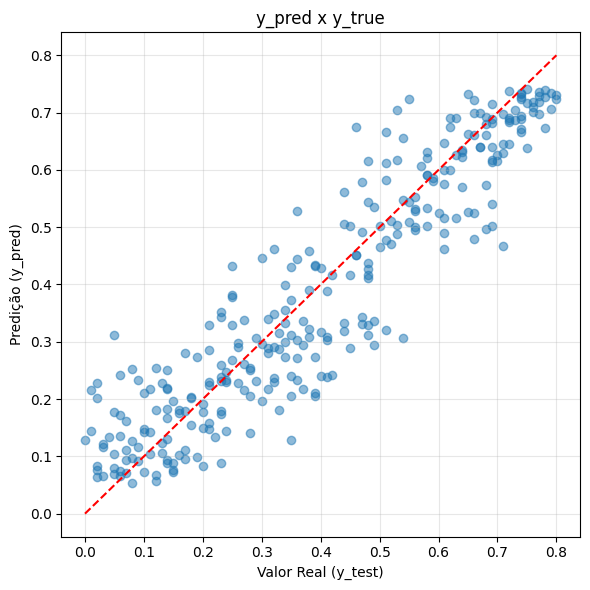

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)

# gráfico y_pred x y_true
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

melhor resultado :(

### RandomForest

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    selected_features, y, test_size=0.3, random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestRegressor

def objective(trial):

    params = {
        # n_estimators: Número de árvores na floresta (similar ao XGBoost)
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
        
        # max_depth: Profundidade máxima da árvore (similar ao XGBoost)
        # RFs podem se beneficiar de árvores mais profundas
        "max_depth": trial.suggest_int("max_depth", 10, 60),
        
        # min_samples_split: O número mínimo de amostras necessárias para dividir um nó
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        
        # min_samples_leaf: O número mínimo de amostras necessárias em um nó folha
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        
        # max_features: O número de features a considerar ao procurar o melhor split
        # Equivalente ao 'colsample_bytree' do XGBoost
        "max_features": trial.suggest_float("max_features", 0.1, 1.0),
    }

    # Instancia o RandomForestRegressor com os parâmetros sugeridos
    # n_jobs=-1 usa todos os processadores para acelerar o treinamento
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse  # Optuna vai minimizar isso

# --- Rodar o estudo (exatamente como antes) ---
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective, n_trials=200, show_progress_bar=True)

print("\n--- Resultados do RandomForest ---")
print("Melhores parâmetros:", study_rf.best_params)
print("Melhor RMSE:", study_rf.best_value)

[I 2025-11-11 16:36:31,050] A new study created in memory with name: no-name-6e042946-348c-43d8-92fe-0808d6821f40
Best trial: 0. Best value: 0.0907351:   0%|          | 1/200 [00:04<13:35,  4.10s/it]

[I 2025-11-11 16:36:35,138] Trial 0 finished with value: 0.09073511557511241 and parameters: {'n_estimators': 1248, 'max_depth': 48, 'min_samples_split': 4, 'min_samples_leaf': 29, 'max_features': 0.9863727127887651}. Best is trial 0 with value: 0.09073511557511241.


Best trial: 1. Best value: 0.0895862:   1%|          | 2/200 [00:07<11:25,  3.46s/it]

[I 2025-11-11 16:36:38,164] Trial 1 finished with value: 0.08958624255013933 and parameters: {'n_estimators': 1170, 'max_depth': 53, 'min_samples_split': 12, 'min_samples_leaf': 21, 'max_features': 0.5663197996081029}. Best is trial 1 with value: 0.08958624255013933.


Best trial: 2. Best value: 0.0893908:   2%|▏         | 3/200 [00:10<11:34,  3.52s/it]

...

[I 2025-11-11 16:52:23,466] Trial 197 finished with value: 0.08897026842296284 and parameters: {'n_estimators': 1966, 'max_depth': 58, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 0.18469965999033047}. Best is trial 167 with value: 0.08863572761649728.


Best trial: 167. Best value: 0.0886357: 100%|█████████▉| 199/200 [15:55<00:03,  3.40s/it]

[I 2025-11-11 16:52:26,875] Trial 198 finished with value: 0.08902395502619531 and parameters: {'n_estimators': 1835, 'max_depth': 60, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.14868721913884866}. Best is trial 167 with value: 0.08863572761649728.


Best trial: 167. Best value: 0.0886357: 100%|██████████| 200/200 [15:59<00:00,  4.80s/it]

[I 2025-11-11 16:52:30,171] Trial 199 finished with value: 0.08895571598191536 and parameters: {'n_estimators': 1892, 'max_depth': 27, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 0.1678220742833857}. Best is trial 167 with value: 0.08863572761649728.

--- Resultados do RandomForest ---
Melhores parâmetros: {'n_estimators': 1857, 'max_depth': 60, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.17509945248733047}
Melhor RMSE: 0.08863572761649728


In [22]:
best_params_rf = study_rf.best_params

final_rf_model = RandomForestRegressor(**best_params_rf, 
                                     random_state=42, 
                                     n_jobs=-1)

final_rf_model.fit(X_train, y_train)

y_pred = final_rf_model.predict(X_test)

# (Opcional) Calcular o RMSE final para confirmar
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRMSE Final no Teste: {final_rmse:.4f}")
print(f"(Melhor RMSE do Optuna: {study_rf.best_value:.4f})")


RMSE Final no Teste: 0.0886
(Melhor RMSE do Optuna: 0.0886)


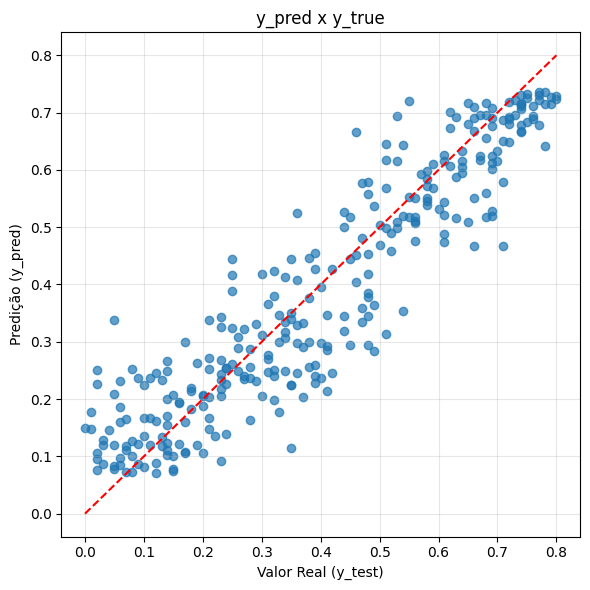

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)

# gráfico y_pred x y_true
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### MLP

In [ ]:
X = torch.Tensor(np.array(selected_features))
y = torch.Tensor(np.array(y).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [ ]:
X.shape[1]

In [ ]:
model = nn.Sequential(
    # (Entrada -> 512 neurônios)
    nn.Linear(X.shape[1], 512),
    nn.BatchNorm1d(512),  # Normaliza os 512 neurônios
    nn.ReLU(),
    nn.Dropout(p=0.3),    # Dropout de 30%

    # (512 -> 256 neurônios)
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    # (256 -> 128 neurônios)
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.2),    

    # (128 -> 1 neurônio)
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

# O otimizador e a função de perda podem ser os mesmos por enquanto
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

In [ ]:
epochs = 50
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('L1 error')
plt.legend()
plt.show()

### MLP (with sklearn and opttimizer)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    selected_features, y, test_size=0.3, random_state=42
)

# Função objetivo (RMSE)
def objective(trial):

    hidden_layers = trial.suggest_int("hidden_layers", 1, 4)

    # criar tupla com tamanho de cada camada
    layer_sizes = tuple(
        trial.suggest_int(f"n_units_layer_{i}", 32, 512)
        for i in range(hidden_layers)
    )

    params = {
        "hidden_layer_sizes": layer_sizes,
        "activation": trial.suggest_categorical("activation", ["relu", "tanh"]),
        "solver": trial.suggest_categorical("solver", ["adam", "lbfgs"]),
        "alpha": trial.suggest_float("alpha", 1e-6, 1e-2, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-5, 1e-2, log=True),
        "max_iter": 500,
        "random_state": 42,
    }

    model = MLPRegressor(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

# Rodar Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Melhores parâmetros:", study.best_params)
print("Melhor RMSE:", study.best_value)

In [ ]:
import matplotlib.pyplot as plt

df_trials = study.trials_dataframe()

# Remove colunas úteis do Optuna
param_cols = [c for c in df_trials.columns if c.startswith("params_")]

for col in param_cols:
    plt.figure(figsize=(7,4))
    plt.plot(df_trials["number"], df_trials[col], marker="o", linestyle="-")
    plt.xlabel("Trial")
    plt.ylabel(col.replace("params_", ""))
    plt.title(f"Evolução do parâmetro: {col.replace('params_', '')}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### KAN

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    selected_features, y, test_size=0.3, random_state=42
)

# rede mínima
model = KAN(
    width=[X_train.shape[1], 64, 1],   # input_dim → hidden → output
    grid=10                           # resolução dos splines
)

model.fit(
    X_train.values, 
    y_train.values.reshape(-1, 1), 
    steps=2000,
    lr=1e-3,
    batch=64
)

preds = model(X_test.values).flatten()

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                         | 0/2000 [00:00<?, ?it/s]

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# TSFresh (500)

In [96]:
X_2 = df.iloc[:, :700]
y = df['y']

# converter wide -> long format (TSFresh input)
df_long_2 = X_2.copy()
df_long_2['id'] = df_long_2.index

df_long_2 = df_long_2.melt(
    id_vars='id',
    var_name='time',
    value_name='value'
)

df_long_2

,id,time,value
0,0,0,0.808799
1,1,0,0.806849
2,2,0,0.730200
3,3,0,0.821097
4,4,0,0.735200
...,...,...,...
699995,995,699,0.000000
699996,996,699,0.036372
699997,997,699,0.000000
699998,998,699,0.000000


In [57]:
extracted_features_2 = extract_features(
    df_long_2,
    column_id="id",
    column_sort="time",
    default_fc_parameters=ComprehensiveFCParameters(),  # or EfficientFCParameters()
    impute_function=None
)

Feature Extraction: 100%|██████████| 334/334 [00:34<00:00,  9.79it/s]


In [59]:
extracted_features_2

,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,value__median,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.0,1.0,1.0,92.974813,33.780937,0.119833,-0.000755,-0.000022,0.064635,...,0.357079,0.581697,1.847783,1.777337,3.132048,4.636511,5.868235,6.394879,NaN,0.779754
1,0.0,0.0,1.0,1.0,94.074139,34.648773,0.119532,-0.000615,0.000067,0.066990,...,0.357079,0.524467,1.865403,1.783926,3.143664,4.655753,5.896685,6.410105,NaN,0.789149
2,0.0,0.0,1.0,1.0,98.874877,37.054678,0.120148,-0.000560,-0.000024,0.069277,...,0.400927,0.550109,1.727666,1.780492,3.138374,4.644201,5.910792,6.397366,NaN,0.774004
3,0.0,0.0,1.0,1.0,72.433564,25.294643,0.110794,-0.000810,0.000092,0.041661,...,0.379592,0.583258,2.039195,1.773201,3.108657,4.574702,5.770037,6.301835,NaN,0.787804
4,0.0,0.0,1.0,1.0,72.896901,25.166481,0.111857,-0.000743,0.000032,0.044929,...,0.379592,0.547475,1.977218,1.773563,3.087320,4.553094,5.782282,6.329675,NaN,0.789152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,1.0,1.0,92.245925,32.850784,0.117628,-0.000565,-0.000069,0.064609,...,0.379592,0.633299,1.826539,1.777006,3.136622,4.627453,5.910468,6.414365,NaN,0.767459
996,0.0,0.0,1.0,1.0,79.638894,28.613584,0.113994,-0.000759,0.000018,0.046381,...,0.357079,0.550109,1.898696,1.761393,3.093209,4.578459,5.753024,6.338155,NaN,0.790652
997,0.0,0.0,1.0,1.0,83.810073,27.791450,0.110572,-0.000894,0.000087,0.059484,...,0.357079,0.573048,1.877155,1.780026,3.123962,4.596459,5.828017,6.368382,NaN,0.761102
998,0.0,0.0,1.0,1.0,73.911279,26.137248,0.109760,-0.000812,-0.000032,0.040572,...,0.357079,0.535750,1.964179,1.772066,3.097388,4.579944,5.786956,6.317465,NaN,0.789968


In [56]:
impute(extracted_features_2)

/opt/venvs/torch/lib/python3.10/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning:

The columns ['value__friedrich_coefficients__coeff_0__m_3__r_30'
 'value__friedrich_coefficients__coeff_1__m_3__r_30'
 'value__friedrich_coefficients__coeff_2__m_3__r_30'
 'value__friedrich_coefficients__coeff_3__m_3__r_30'
 'value__max_langevin_fixed_point__m_3__r_30'
 'value__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.



,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,value__median,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.0,1.0,1.0,92.974813,33.780937,0.119833,-0.000755,-0.000022,0.064635,...,0.357079,0.581697,1.847783,1.777337,3.132048,4.636511,5.868235,6.394879,0.0,0.779754
1,0.0,0.0,1.0,1.0,94.074139,34.648773,0.119532,-0.000615,0.000067,0.066990,...,0.357079,0.524467,1.865403,1.783926,3.143664,4.655753,5.896685,6.410105,0.0,0.789149
2,0.0,0.0,1.0,1.0,98.874877,37.054678,0.120148,-0.000560,-0.000024,0.069277,...,0.400927,0.550109,1.727666,1.780492,3.138374,4.644201,5.910792,6.397366,0.0,0.774004
3,0.0,0.0,1.0,1.0,72.433564,25.294643,0.110794,-0.000810,0.000092,0.041661,...,0.379592,0.583258,2.039195,1.773201,3.108657,4.574702,5.770037,6.301835,0.0,0.787804
4,0.0,0.0,1.0,1.0,72.896901,25.166481,0.111857,-0.000743,0.000032,0.044929,...,0.379592,0.547475,1.977218,1.773563,3.087320,4.553094,5.782282,6.329675,0.0,0.789152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,1.0,1.0,92.245925,32.850784,0.117628,-0.000565,-0.000069,0.064609,...,0.379592,0.633299,1.826539,1.777006,3.136622,4.627453,5.910468,6.414365,0.0,0.767459
996,0.0,0.0,1.0,1.0,79.638894,28.613584,0.113994,-0.000759,0.000018,0.046381,...,0.357079,0.550109,1.898696,1.761393,3.093209,4.578459,5.753024,6.338155,0.0,0.790652
997,0.0,0.0,1.0,1.0,83.810073,27.791450,0.110572,-0.000894,0.000087,0.059484,...,0.357079,0.573048,1.877155,1.780026,3.123962,4.596459,5.828017,6.368382,0.0,0.761102
998,0.0,0.0,1.0,1.0,73.911279,26.137248,0.109760,-0.000812,-0.000032,0.040572,...,0.357079,0.535750,1.964179,1.772066,3.097388,4.579944,5.786956,6.317465,0.0,0.789968


In [62]:
select_features(impute(extracted_features_2), y, ml_task='regression',)

,"value__agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",value__standard_deviation,value__variance,"value__fft_coefficient__attr_""real""__coeff_1","value__linear_trend__attr_""stderr""","value__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""mean""","value__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","value__fft_coefficient__attr_""abs""__coeff_1",value__kurtosis,value__quantile__q_0.9,...,"value__fft_coefficient__attr_""angle""__coeff_76","value__fft_coefficient__attr_""real""__coeff_95","value__fft_coefficient__attr_""imag""__coeff_93","value__fft_coefficient__attr_""imag""__coeff_78","value__fft_coefficient__attr_""real""__coeff_29","value__fft_coefficient__attr_""imag""__coeff_37","value__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)","value__fft_coefficient__attr_""abs""__coeff_46","value__agg_linear_trend__attr_""rvalue""__chunk_len_50__f_agg_""max""","value__fft_coefficient__attr_""angle""__coeff_85"
0,0.004879,0.174977,0.030617,25.577090,0.000032,0.000210,0.000491,31.213171,2.946604,0.385702,...,-106.700394,-2.071497,-0.467557,1.078667,2.221840,-0.105474,0.561633,0.372335,-0.395918,-51.399320
1,0.005186,0.177305,0.031437,25.337013,0.000032,0.000216,0.000516,30.570575,3.028100,0.394321,...,-144.920521,-0.306507,0.764068,-0.721745,2.712017,0.272926,0.525014,3.226919,-0.320453,-83.306857
2,0.005515,0.181614,0.032984,28.312495,0.000033,0.000227,0.000546,34.229054,2.087813,0.433748,...,-100.332149,-2.539736,-0.114893,0.170894,2.395217,1.301387,0.509654,2.938119,-0.355607,-7.486823
3,0.004074,0.159461,0.025428,19.835010,0.000030,0.000189,0.000426,22.167407,5.425095,0.320774,...,-84.779431,-1.306222,0.214324,-0.003234,2.420876,2.336904,0.555698,0.493573,-0.472348,134.697480
4,0.003686,0.158453,0.025107,17.694020,0.000029,0.000179,0.000387,20.927320,5.984042,0.316884,...,-105.603894,-1.125912,-0.233289,0.170992,1.077836,0.161378,0.525444,2.007684,-0.403123,-132.222271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.004799,0.171941,0.029564,24.345625,0.000031,0.000207,0.000484,29.688598,3.347589,0.387840,...,-103.267383,-0.837101,0.126331,-0.237746,2.192788,1.161811,0.497873,1.253709,-0.511290,-7.250312
996,0.004519,0.167132,0.027933,22.759240,0.000031,0.000197,0.000452,26.869740,4.234053,0.353657,...,-91.635597,-0.428712,0.805800,-0.085231,1.990819,0.937478,0.535769,2.420809,-0.563870,-0.558251
997,0.004413,0.159271,0.025367,23.114493,0.000029,0.000189,0.000441,27.716096,3.961565,0.340141,...,-100.232393,-2.245200,0.223942,-1.304382,1.132560,0.111600,0.521773,1.934135,-0.363001,-99.959459
998,0.004248,0.161834,0.026190,21.062881,0.000030,0.000192,0.000435,23.982710,5.152556,0.320792,...,-101.868259,-2.326794,0.181650,-0.149930,1.595115,0.350784,0.583505,1.550973,-0.503555,-30.543790


In [12]:
extracted_features_2 = extract_features(
    df_long_2,
    column_id="id",
    column_sort="time",
    default_fc_parameters=ComprehensiveFCParameters(),  # or EfficientFCParameters()
    impute_function=None
)

extracted_features_2 = impute(extracted_features_2)

selected_features_2 = select_features(extracted_features_2, y)

Feature Extraction: 100%|██████████| 334/334 [00:31<00:00, 10.54it/s]
/opt/venvs/torch/lib/python3.10/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['value__friedrich_coefficients__coeff_0__m_3__r_30'
 'value__friedrich_coefficients__coeff_1__m_3__r_30'
 'value__friedrich_coefficients__coeff_2__m_3__r_30'
 'value__friedrich_coefficients__coeff_3__m_3__r_30'
 'value__max_langevin_fixed_point__m_3__r_30'
 'value__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [68]:
selected_features_2

,"value__agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",value__standard_deviation,value__variance,"value__fft_coefficient__attr_""real""__coeff_1","value__linear_trend__attr_""stderr""","value__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""mean""","value__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","value__fft_coefficient__attr_""abs""__coeff_1",value__kurtosis,value__quantile__q_0.9,...,"value__fft_coefficient__attr_""angle""__coeff_76","value__fft_coefficient__attr_""real""__coeff_95","value__fft_coefficient__attr_""imag""__coeff_93","value__fft_coefficient__attr_""imag""__coeff_78","value__fft_coefficient__attr_""real""__coeff_29","value__fft_coefficient__attr_""imag""__coeff_37","value__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)","value__fft_coefficient__attr_""abs""__coeff_46","value__agg_linear_trend__attr_""rvalue""__chunk_len_50__f_agg_""max""","value__fft_coefficient__attr_""angle""__coeff_85"
0,0.004879,0.174977,0.030617,25.577090,0.000032,0.000210,0.000491,31.213171,2.946604,0.385702,...,-106.700394,-2.071497,-0.467557,1.078667,2.221840,-0.105474,0.561633,0.372335,-0.395918,-51.399320
1,0.005186,0.177305,0.031437,25.337013,0.000032,0.000216,0.000516,30.570575,3.028100,0.394321,...,-144.920521,-0.306507,0.764068,-0.721745,2.712017,0.272926,0.525014,3.226919,-0.320453,-83.306857
2,0.005515,0.181614,0.032984,28.312495,0.000033,0.000227,0.000546,34.229054,2.087813,0.433748,...,-100.332149,-2.539736,-0.114893,0.170894,2.395217,1.301387,0.509654,2.938119,-0.355607,-7.486823
3,0.004074,0.159461,0.025428,19.835010,0.000030,0.000189,0.000426,22.167407,5.425095,0.320774,...,-84.779431,-1.306222,0.214324,-0.003234,2.420876,2.336904,0.555698,0.493573,-0.472348,134.697480
4,0.003686,0.158453,0.025107,17.694020,0.000029,0.000179,0.000387,20.927320,5.984042,0.316884,...,-105.603894,-1.125912,-0.233289,0.170992,1.077836,0.161378,0.525444,2.007684,-0.403123,-132.222271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.004799,0.171941,0.029564,24.345625,0.000031,0.000207,0.000484,29.688598,3.347589,0.387840,...,-103.267383,-0.837101,0.126331,-0.237746,2.192788,1.161811,0.497873,1.253709,-0.511290,-7.250312
996,0.004519,0.167132,0.027933,22.759240,0.000031,0.000197,0.000452,26.869740,4.234053,0.353657,...,-91.635597,-0.428712,0.805800,-0.085231,1.990819,0.937478,0.535769,2.420809,-0.563870,-0.558251
997,0.004413,0.159271,0.025367,23.114493,0.000029,0.000189,0.000441,27.716096,3.961565,0.340141,...,-100.232393,-2.245200,0.223942,-1.304382,1.132560,0.111600,0.521773,1.934135,-0.363001,-99.959459
998,0.004248,0.161834,0.026190,21.062881,0.000030,0.000192,0.000435,23.982710,5.152556,0.320792,...,-101.868259,-2.326794,0.181650,-0.149930,1.595115,0.350784,0.583505,1.550973,-0.503555,-30.543790


In [82]:
## test features

X_submissão = test

# converter wide -> long format (TSFresh input)
df_long_test = X_submissão.copy()
df_long_test['id'] = df_long_test.index

df_long_test = df_long_test.melt(
    id_vars='id',
    var_name='time',
    value_name='value'
)

extracted_features_test = extract_features(
    df_long_test,
    column_id="id",
    column_sort="time",
    default_fc_parameters=ComprehensiveFCParameters(),  # or EfficientFCParameters()
    impute_function=None
)

extracted_features_test = impute(extracted_features_test)
selected_features_test = extracted_features_test.loc[:, selected_features_2.columns]

Feature Extraction: 100%|██████████| 334/334 [00:32<00:00, 10.32it/s]
/opt/venvs/torch/lib/python3.10/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning:

The columns ['value__friedrich_coefficients__coeff_0__m_3__r_30'
 'value__friedrich_coefficients__coeff_1__m_3__r_30'
 'value__friedrich_coefficients__coeff_2__m_3__r_30'
 'value__friedrich_coefficients__coeff_3__m_3__r_30'
 'value__max_langevin_fixed_point__m_3__r_30'
 'value__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.



In [81]:
selected_features_test

,"value__agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",value__standard_deviation,value__variance,"value__fft_coefficient__attr_""real""__coeff_1","value__linear_trend__attr_""stderr""","value__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""mean""","value__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","value__fft_coefficient__attr_""abs""__coeff_1",value__kurtosis,value__quantile__q_0.9,...,"value__fft_coefficient__attr_""angle""__coeff_76","value__fft_coefficient__attr_""real""__coeff_95","value__fft_coefficient__attr_""imag""__coeff_93","value__fft_coefficient__attr_""imag""__coeff_78","value__fft_coefficient__attr_""real""__coeff_29","value__fft_coefficient__attr_""imag""__coeff_37","value__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)","value__fft_coefficient__attr_""abs""__coeff_46","value__agg_linear_trend__attr_""rvalue""__chunk_len_50__f_agg_""max""","value__fft_coefficient__attr_""angle""__coeff_85"
0,0.004879,0.174977,0.030617,25.577090,0.000032,0.000210,0.000491,31.213171,2.946604,0.385702,...,-106.700394,-2.071497,-0.467557,1.078667,2.221840,-0.105474,0.561633,0.372335,-0.395918,-51.399320
1,0.005186,0.177305,0.031437,25.337013,0.000032,0.000216,0.000516,30.570575,3.028100,0.394321,...,-144.920521,-0.306507,0.764068,-0.721745,2.712017,0.272926,0.525014,3.226919,-0.320453,-83.306857
2,0.005515,0.181614,0.032984,28.312495,0.000033,0.000227,0.000546,34.229054,2.087813,0.433748,...,-100.332149,-2.539736,-0.114893,0.170894,2.395217,1.301387,0.509654,2.938119,-0.355607,-7.486823
3,0.004074,0.159461,0.025428,19.835010,0.000030,0.000189,0.000426,22.167407,5.425095,0.320774,...,-84.779431,-1.306222,0.214324,-0.003234,2.420876,2.336904,0.555698,0.493573,-0.472348,134.697480
4,0.003686,0.158453,0.025107,17.694020,0.000029,0.000179,0.000387,20.927320,5.984042,0.316884,...,-105.603894,-1.125912,-0.233289,0.170992,1.077836,0.161378,0.525444,2.007684,-0.403123,-132.222271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.004799,0.171941,0.029564,24.345625,0.000031,0.000207,0.000484,29.688598,3.347589,0.387840,...,-103.267383,-0.837101,0.126331,-0.237746,2.192788,1.161811,0.497873,1.253709,-0.511290,-7.250312
996,0.004519,0.167132,0.027933,22.759240,0.000031,0.000197,0.000452,26.869740,4.234053,0.353657,...,-91.635597,-0.428712,0.805800,-0.085231,1.990819,0.937478,0.535769,2.420809,-0.563870,-0.558251
997,0.004413,0.159271,0.025367,23.114493,0.000029,0.000189,0.000441,27.716096,3.961565,0.340141,...,-100.232393,-2.245200,0.223942,-1.304382,1.132560,0.111600,0.521773,1.934135,-0.363001,-99.959459
998,0.004248,0.161834,0.026190,21.062881,0.000030,0.000192,0.000435,23.982710,5.152556,0.320792,...,-101.868259,-2.326794,0.181650,-0.149930,1.595115,0.350784,0.583505,1.550973,-0.503555,-30.543790


In [83]:
selected_features_test

,"value__agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",value__standard_deviation,value__variance,"value__fft_coefficient__attr_""real""__coeff_1","value__linear_trend__attr_""stderr""","value__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""mean""","value__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","value__fft_coefficient__attr_""abs""__coeff_1",value__kurtosis,value__quantile__q_0.9,...,"value__fft_coefficient__attr_""angle""__coeff_76","value__fft_coefficient__attr_""real""__coeff_95","value__fft_coefficient__attr_""imag""__coeff_93","value__fft_coefficient__attr_""imag""__coeff_78","value__fft_coefficient__attr_""real""__coeff_29","value__fft_coefficient__attr_""imag""__coeff_37","value__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)","value__fft_coefficient__attr_""abs""__coeff_46","value__agg_linear_trend__attr_""rvalue""__chunk_len_50__f_agg_""max""","value__fft_coefficient__attr_""angle""__coeff_85"
0,0.005270,0.182736,0.033392,25.153336,0.000034,0.000228,0.000529,30.190429,3.308110,0.396353,...,-110.650542,-1.784311,-0.442972,0.146491,1.539391,1.654845,0.503776,0.536318,-0.325472,-1.335263
1,0.003792,0.163455,0.026717,17.952642,0.000030,0.000184,0.000399,19.878339,6.036694,0.312444,...,-102.350210,-1.004351,1.029698,-0.224689,1.828509,0.998996,0.553544,1.221460,-0.404905,-165.925525
2,0.005856,0.198212,0.039288,30.568176,0.000036,0.000242,0.000582,37.708687,2.414838,0.469219,...,-96.528549,-0.829541,0.098059,0.128392,3.043896,0.729711,0.598394,0.614333,-0.454040,-32.434413
3,0.005010,0.184544,0.034056,24.404112,0.000034,0.000217,0.000514,30.075349,3.687690,0.383817,...,-132.595168,-0.838701,-1.027150,1.869624,1.894736,1.469064,0.681331,0.643221,-0.541512,-4.043435
4,0.006074,0.194231,0.037726,32.791777,0.000035,0.000245,0.000594,40.305908,1.568341,0.476100,...,-88.322278,-1.712286,-0.134162,-1.124492,1.234540,1.182297,0.542094,0.737917,-0.543931,-15.534359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.005525,0.189511,0.035914,27.256136,0.000035,0.000233,0.000559,32.879636,2.993958,0.418946,...,-82.469629,-2.314680,-0.893977,-0.325328,1.594858,2.025533,0.590395,1.346625,-0.456261,-73.305072
996,0.003619,0.159298,0.025376,16.929285,0.000030,0.000185,0.000406,19.011273,6.740267,0.303536,...,-71.167802,-2.095013,-0.734755,0.548865,1.891327,-0.111473,0.586040,0.674477,-0.423119,-26.753289
997,0.005876,0.194688,0.037903,29.380289,0.000035,0.000247,0.000601,35.849077,2.317820,0.462648,...,-58.250893,-1.409139,0.428072,-0.520451,2.006576,2.235002,0.554292,1.466390,-0.524603,-38.344895
998,0.005587,0.190814,0.036410,27.160258,0.000035,0.000235,0.000566,33.451967,2.590116,0.448759,...,-138.252120,-2.159498,-0.516940,1.282706,0.700533,1.574973,0.589099,1.895530,-0.503508,159.369025


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    selected_features_2, y, test_size=0.2, random_state=42
)

### função objetivo
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 1500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.01, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 22),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse  # Optuna vai minimizar isso

# Rodar o estudo
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Melhores parâmetros:", study.best_params)
print("Melhor RMSE:", study.best_value)

[I 2025-11-12 14:20:14,142] A new study created in memory with name: no-name-e98b471b-ce09-413f-a189-3512e613d4ce
Best trial: 0. Best value: 0.102792:   2%|▏         | 1/50 [00:03<03:10,  3.89s/it]

[I 2025-11-12 14:20:18,033] Trial 0 finished with value: 0.1027915410925431 and parameters: {'n_estimators': 1827, 'learning_rate': 0.00415291635743681, 'max_depth': 5, 'subsample': 0.7279386713823535, 'colsample_bytree': 0.5475457220823704, 'min_child_weight': 1, 'gamma': 1.5410656863478729}. Best is trial 0 with value: 0.1027915410925431.


Best trial: 0. Best value: 0.102792:   4%|▍         | 2/50 [00:09<03:52,  4.83s/it]

[I 2025-11-12 14:20:23,524] Trial 1 finished with value: 0.19057557943484654 and parameters: {'n_estimators': 2271, 'learning_rate': 0.00012714239365662413, 'max_depth': 10, 'subsample': 0.8142369434207954, 'colsample_bytree': 0.7226812724979408, 'min_child_weight': 6, 'gamma': 3.001623237914864}. Best is trial 0 with value: 0.1027915410925431.


Best trial: 0. Best value: 0.102792:   6%|▌         | 3/50 [00:15<04:14,  5.42s/it]

...

[I 2025-11-12 14:24:42,022] Trial 47 finished with value: 0.09649404101130436 and parameters: {'n_estimators': 2563, 'learning_rate': 0.006256858957912052, 'max_depth': 22, 'subsample': 0.878428418290117, 'colsample_bytree': 0.5642938363333155, 'min_child_weight': 1, 'gamma': 1.099525454773154}. Best is trial 43 with value: 0.08347793592448609.


Best trial: 43. Best value: 0.0834779:  98%|█████████▊| 49/50 [04:35<00:04,  4.89s/it]

[I 2025-11-12 14:24:49,358] Trial 48 finished with value: 0.08670432963284888 and parameters: {'n_estimators': 2454, 'learning_rate': 0.009944595633293208, 'max_depth': 18, 'subsample': 0.9928910209148345, 'colsample_bytree': 0.6308216175842034, 'min_child_weight': 1, 'gamma': 0.003145331627275698}. Best is trial 43 with value: 0.08347793592448609.


Best trial: 43. Best value: 0.0834779: 100%|██████████| 50/50 [04:39<00:00,  5.58s/it]

[I 2025-11-12 14:24:53,189] Trial 49 finished with value: 0.08834761702588308 and parameters: {'n_estimators': 2649, 'learning_rate': 0.007772765074571589, 'max_depth': 20, 'subsample': 0.9489456193126597, 'colsample_bytree': 0.7000294063212226, 'min_child_weight': 2, 'gamma': 0.45990197817300194}. Best is trial 43 with value: 0.08347793592448609.
Melhores parâmetros: {'n_estimators': 2585, 'learning_rate': 0.00924824887077673, 'max_depth': 20, 'subsample': 0.9551046301534873, 'colsample_bytree': 0.6144910467136335, 'min_child_weight': 1, 'gamma': 0.043701343599216715}
Melhor RMSE: 0.08347793592448609


RMSE final: 0.08347793592448609


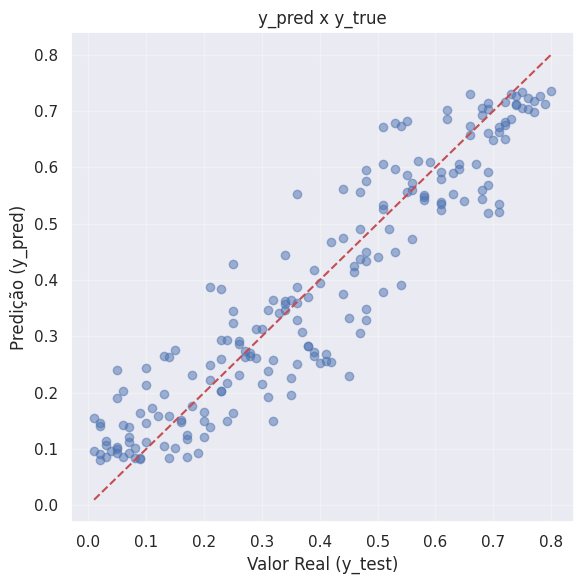

In [31]:
best_params_XGBoost = study.best_params

model = XGBRegressor(**best_params_XGBoost)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE final:", rmse)
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)

# gráfico y_pred x y_true
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Gráfico de evolução dos hiperparâmetros salvo como 'evolucao_hiperparametros.png'


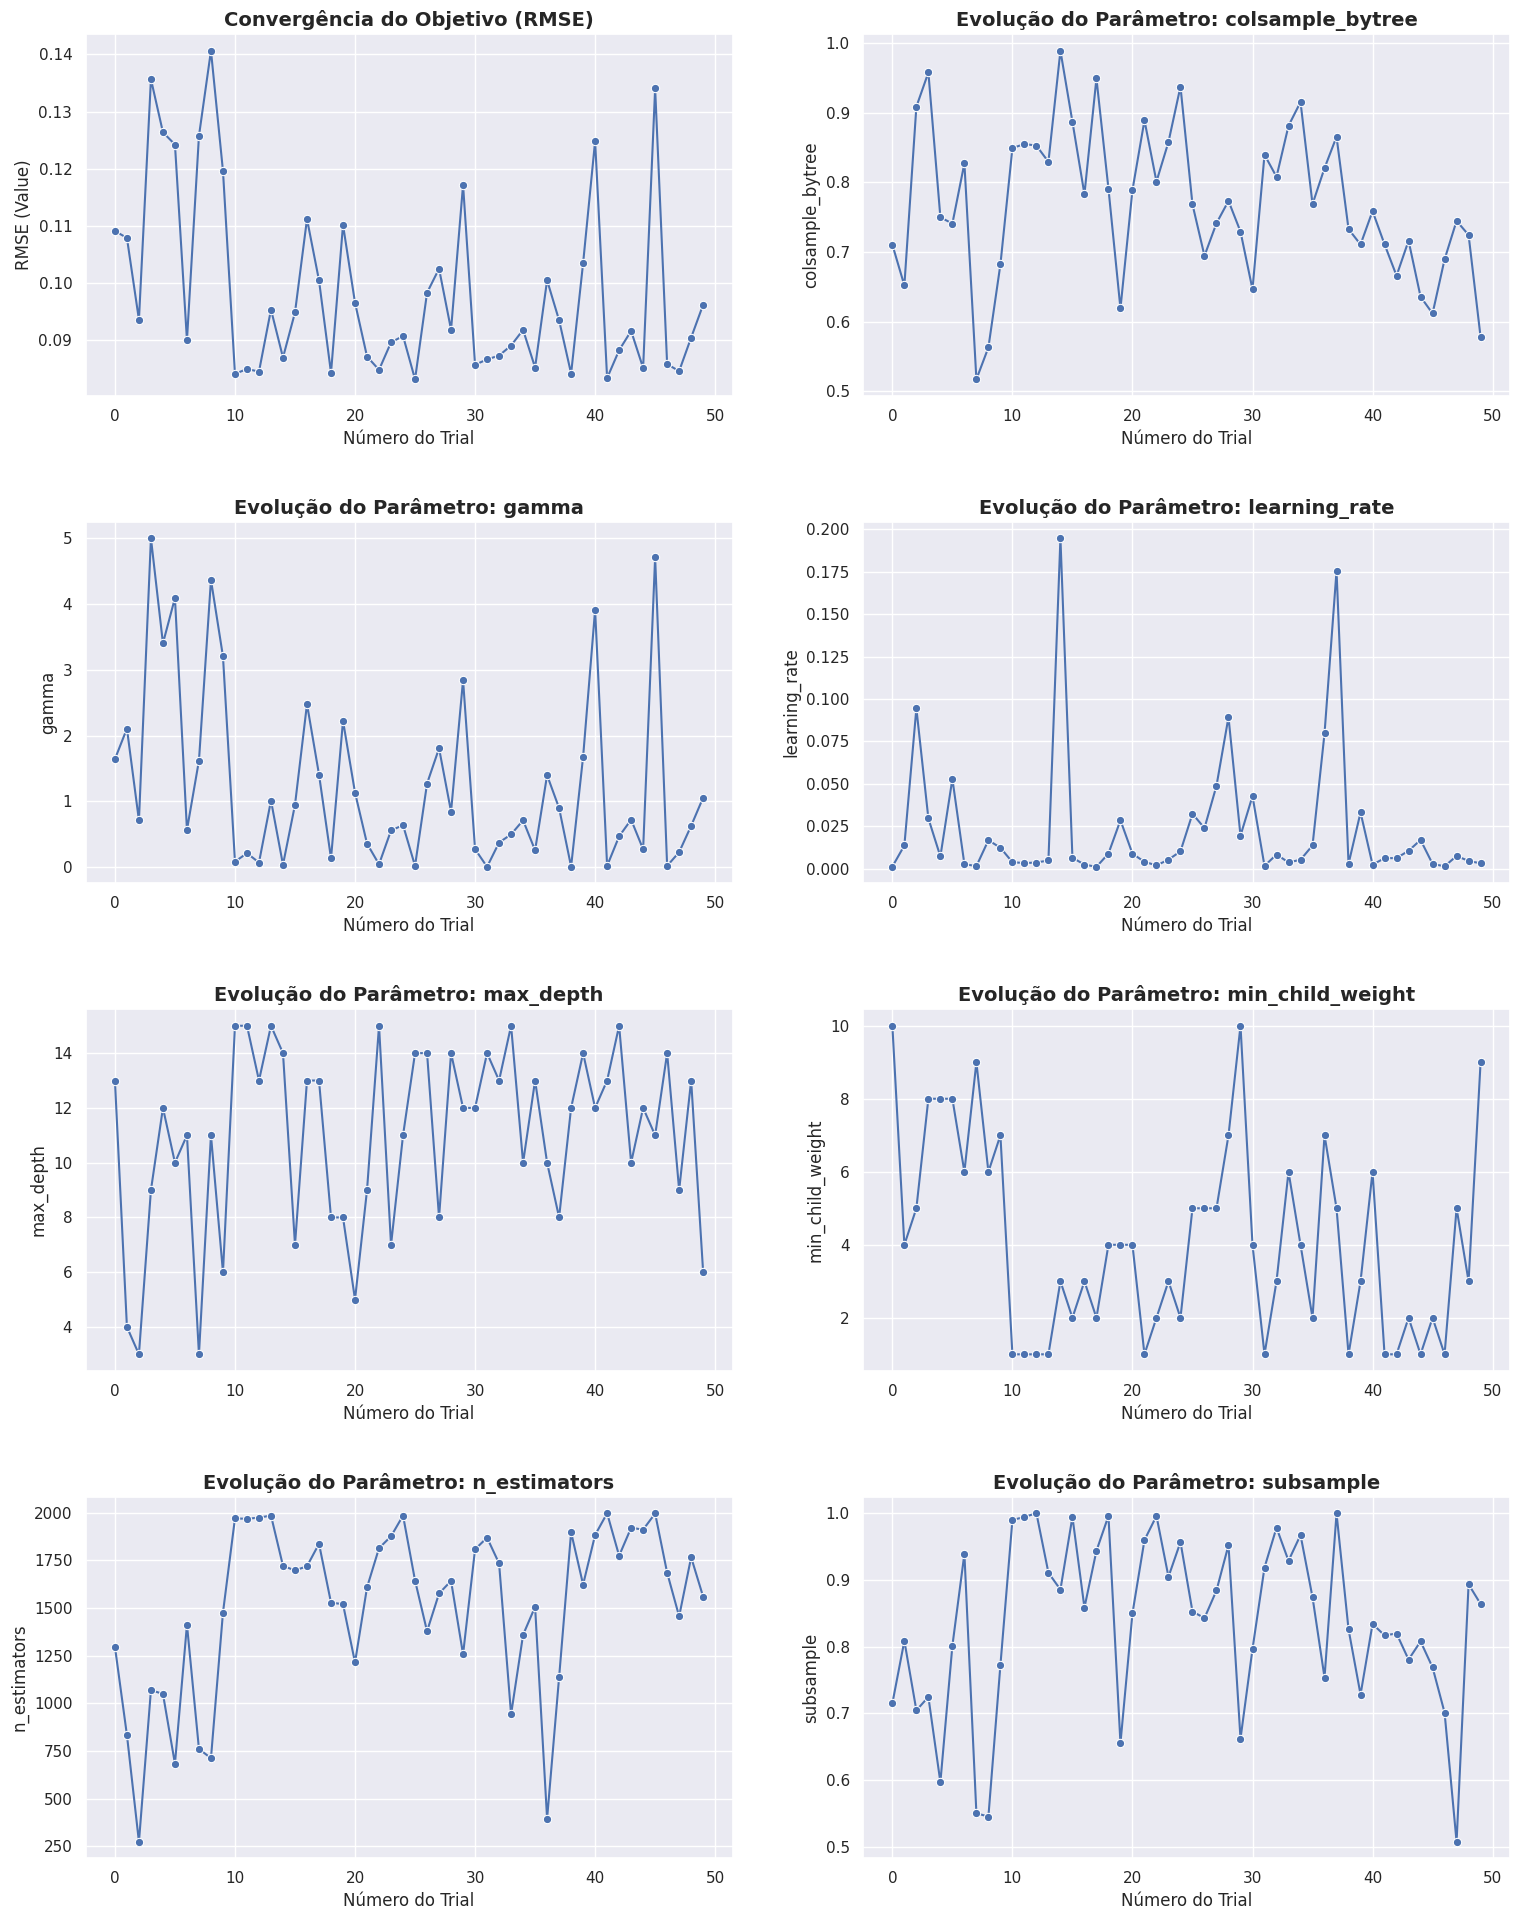

In [32]:
sns.set_theme(style="darkgrid", palette="deep")

# 2. Listar todas as colunas que queremos plotar
columns_to_plot = [
    'value', 
    'params_colsample_bytree', 
    'params_gamma', 
    'params_learning_rate', 
    'params_max_depth', 
    'params_min_child_weight', 
    'params_n_estimators', 
    'params_subsample'
]

# 3. Criar a grade de subplots (4 linhas, 2 colunas)
fig, axes = plt.subplots(4, 2, figsize=(16, 20)) # (Largura, Altura)
# Achatar o array de eixos para facilitar a iteração
axes = axes.flatten()

# 4. Iterar e criar cada plot
for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    
    # Usar sns.lineplot para um visual melhor
    sns.lineplot(
        data=df_trials,
        x='number',
        y=col,
        ax=ax,
        marker='o', # Adicionar marcadores como no original
        label=col
    )
    
    # 5. Definir títulos e labels "limpos"
    if col == 'value':
        title = "Convergência do Objetivo (RMSE)"
        ylabel = "RMSE (Value)"
    else:
        # Remove 'params_' para um título mais limpo
        param_name = col.replace('params_', '')
        title = f"Evolução do Parâmetro: {param_name}"
        ylabel = param_name
        
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Número do Trial", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Remover legenda de cada subplot (não é necessária)
    ax.get_legend().remove()

# 6. Ajustar layout para evitar sobreposição
plt.tight_layout(pad=3.0) # Adicionar um pouco de preenchimento

# 7. Salvar a figura
plot_filename = "evolucao_hiperparametros.png"
plt.savefig(plot_filename)

print(f"Gráfico de evolução dos hiperparâmetros salvo como '{plot_filename}'")

In [105]:
### Arquivo da submissão
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

y_pred = model.predict(selected_features_test)
XGBoost_raw_data = write_csv_file(y_pred)
XGBoost_raw_data
y_pred

array([0.19982373, 0.63281744, 0.12456625, 0.21856818, 0.0863525 ,
       0.1089073 , 0.26305526, 0.50206435, 0.21952192, 0.30416164,
       0.52389266, 0.42612074, 0.15769141, 0.2074952 , 0.16732596,
       0.57076585, 0.20436245, 0.16971116, 0.1183198 , 0.67002926,
       0.11906926, 0.2729612 , 0.31959937, 0.42242053, 0.30970321,
       0.36133788, 0.12649259, 0.11997397, 0.37161818, 0.13552999,
       0.72155809, 0.09184189, 0.06050477, 0.08016242, 0.63592197,
       0.23045321, 0.50521992, 0.30586937, 0.08987342, 0.6611876 ,
       0.14255844, 0.22809896, 0.54375338, 0.07157743, 0.21591997,
       0.13588019, 0.20107642, 0.22782233, 0.19821928, 0.38332522,
       0.42778066, 0.09989075, 0.09807023, 0.11350647, 0.12277655,
       0.56462812, 0.28167598, 0.51282745, 0.23520846, 0.71033698,
       0.65685882, 0.12616309, 0.21415452, 0.08974908, 0.09774653,
       0.62065331, 0.2038947 , 0.34853117, 0.17348043, 0.3897152 ,
       0.50306257, 0.18018586, 0.21305385, 0.23089801, 0.14682

In [86]:
y_pred

array([0.26809922, 0.2760815 , 0.10885087, 0.6140128 , 0.6971089 ,
       0.33839843, 0.5441825 , 0.35813668, 0.21145138, 0.32884246,
       0.13875219, 0.66178894, 0.6872956 , 0.2838146 , 0.2544497 ,
       0.5473306 , 0.7534336 , 0.5137545 , 0.0944001 , 0.436064  ,
       0.3243687 , 0.6696122 , 0.7214728 , 0.20320576, 0.26299462,
       0.46658376, 0.461165  , 0.31813365, 0.08977352, 0.50185174,
       0.29311588, 0.62393343, 0.71301514, 0.5219342 , 0.09090799,
       0.10587359, 0.46589   , 0.11132507, 0.6603223 , 0.14236495,
       0.44981077, 0.5209617 , 0.10165042, 0.52808744, 0.27455693,
       0.07761095, 0.6425566 , 0.25196096, 0.2856226 , 0.73337585,
       0.5834586 , 0.3389839 , 0.56445545, 0.28660488, 0.6818149 ,
       0.5755589 , 0.45583364, 0.09303305, 0.5159052 , 0.15552868,
       0.28360438, 0.5441115 , 0.1791404 , 0.24417333, 0.3468162 ,
       0.3515665 , 0.4400066 , 0.5522836 , 0.38833335, 0.34315607,
       0.67209506, 0.676646  , 0.5604964 , 0.43265617, 0.60295

RMSE final: 0.10139345350624833


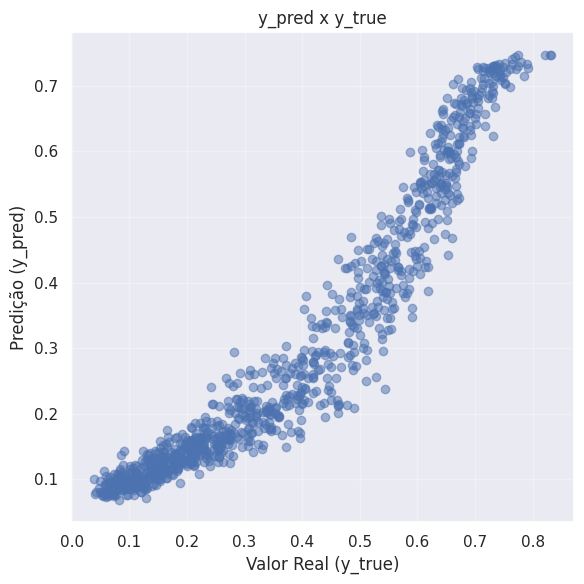

In [91]:
path = 'submissions/time2_trilha1_DWTcurva_PCA.csv'
y_true = pd.read_csv(path, sep='\t').drop('CPMG', axis=1)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE final:", rmse)
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)

# # gráfico y_pred x y_true
# min_val = min(y_true.min(), y_pred.min())
# max_val = max(y_true.max(), y_pred.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_true)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

np.float64(0.72)

In [98]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import optuna
import numpy as np

# Split
X_train, X_test, y_train, y_test = train_test_split(
    selected_features_2, y, test_size=0.3, random_state=42
)

# Função objetivo para Optuna
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),

        # parâmetros fixos recomendados
        "loss_function": "RMSE",
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

# Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Melhores parâmetros:", study.best_params)
print("Melhor RMSE:", study.best_value)


[I 2025-11-12 18:46:58,488] A new study created in memory with name: no-name-c9209d4a-7920-461b-a325-82a152176077
Best trial: 0. Best value: 0.0922679:   2%|▏         | 1/50 [00:35<28:59, 35.49s/it]

[I 2025-11-12 18:47:33,980] Trial 0 finished with value: 0.09226788094850127 and parameters: {'iterations': 1116, 'learning_rate': 0.26016184430976347, 'depth': 9, 'subsample': 0.5894453475425332, 'l2_leaf_reg': 9.982169966829884, 'bagging_temperature': 3.7382777081713217}. Best is trial 0 with value: 0.09226788094850127.


Best trial: 1. Best value: 0.0893593:   4%|▍         | 2/50 [00:58<22:33, 28.20s/it]

[I 2025-11-12 18:47:57,075] Trial 1 finished with value: 0.08935928340379666 and parameters: {'iterations': 834, 'learning_rate': 0.2050271096155677, 'depth': 9, 'subsample': 0.7193656682762981, 'l2_leaf_reg': 2.6212526363354347, 'bagging_temperature': 3.966392195961422}. Best is trial 1 with value: 0.08935928340379666.


Best trial: 1. Best value: 0.0893593:   6%|▌         | 3/50 [01:06<14:43, 18.79s/it]

...

[I 2025-11-12 18:57:19,135] Trial 47 finished with value: 0.09919257331885936 and parameters: {'iterations': 1070, 'learning_rate': 0.0017566357620909853, 'depth': 8, 'subsample': 0.9139543795776426, 'l2_leaf_reg': 2.311402939958487, 'bagging_temperature': 4.06010604203688}. Best is trial 27 with value: 0.08330893011776112.


Best trial: 27. Best value: 0.0833089:  98%|█████████▊| 49/50 [10:30<00:08,  8.63s/it]

[I 2025-11-12 18:57:28,884] Trial 48 finished with value: 0.10492435598007757 and parameters: {'iterations': 1153, 'learning_rate': 0.001406975361051048, 'depth': 7, 'subsample': 0.7209520222684072, 'l2_leaf_reg': 3.496182878988037, 'bagging_temperature': 4.666890282390427}. Best is trial 27 with value: 0.08330893011776112.


Best trial: 27. Best value: 0.0833089: 100%|██████████| 50/50 [10:33<00:00, 12.68s/it]

[I 2025-11-12 18:57:32,256] Trial 49 finished with value: 0.08410213365570629 and parameters: {'iterations': 813, 'learning_rate': 0.005164460756974719, 'depth': 5, 'subsample': 0.6836105096622392, 'l2_leaf_reg': 2.6641945707838732, 'bagging_temperature': 3.485870309723915}. Best is trial 27 with value: 0.08330893011776112.
Melhores parâmetros: {'iterations': 707, 'learning_rate': 0.011545903651370973, 'depth': 6, 'subsample': 0.8736731361036124, 'l2_leaf_reg': 3.194835160823593, 'bagging_temperature': 1.245177965640147}
Melhor RMSE: 0.08330893011776112


0:	learn: 0.2272472	total: 18.3ms	remaining: 12.9s
1:	learn: 0.2253479	total: 33.6ms	remaining: 11.8s
2:	learn: 0.2235198	total: 46.9ms	remaining: 11s
3:	learn: 0.2216973	total: 59.8ms	remaining: 10.5s
4:	learn: 0.2200871	total: 72.2ms	remaining: 10.1s
5:	learn: 0.2183207	total: 84.9ms	remaining: 9.92s
6:	learn: 0.2165939	total: 96.3ms	remaining: 9.63s
7:	learn: 0.2148378	total: 109ms	remaining: 9.53s
8:	learn: 0.2130490	total: 121ms	remaining: 9.4s
9:	learn: 0.2112826	total: 133ms	remaining: 9.3s
10:	learn: 0.2097023	total: 145ms	remaining: 9.18s
11:	learn: 0.2080387	total: 157ms	remaining: 9.12s
12:	learn: 0.2065173	total: 169ms	remaining: 9.03s
13:	learn: 0.2049972	total: 181ms	remaining: 8.94s
14:	learn: 0.2034392	total: 193ms	remaining: 8.9s
15:	learn: 0.2018983	total: 205ms	remaining: 8.85s
16:	learn: 0.2002290	total: 219ms	remaining: 8.9s
17:	learn: 0.1986553	total: 232ms	remaining: 8.88s
18:	learn: 0.1970780	total: 244ms	remaining: 8.82s
19:	learn: 0.1957743	total: 255ms	remain

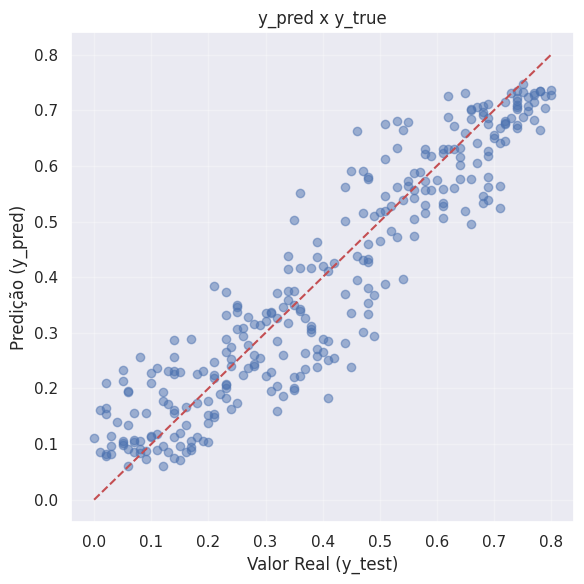

In [99]:
best_params = study.best_params

model = CatBoostRegressor(**best_params)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE final:", rmse)
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)

# gráfico y_pred x y_true
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [103]:
from sklearn.ensemble import RandomForestRegressor

def objective(trial):

    params = {
        # n_estimators: Número de árvores na floresta (similar ao XGBoost)
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
        
        # max_depth: Profundidade máxima da árvore (similar ao XGBoost)
        # RFs podem se beneficiar de árvores mais profundas
        "max_depth": trial.suggest_int("max_depth", 10, 60),
        
        # min_samples_split: O número mínimo de amostras necessárias para dividir um nó
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        
        # min_samples_leaf: O número mínimo de amostras necessárias em um nó folha
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        
        # max_features: O número de features a considerar ao procurar o melhor split
        # Equivalente ao 'colsample_bytree' do XGBoost
        "max_features": trial.suggest_float("max_features", 0.1, 1.0),
    }

    # Instancia o RandomForestRegressor com os parâmetros sugeridos
    # n_jobs=-1 usa todos os processadores para acelerar o treinamento
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse  # Optuna vai minimizar isso

# --- Rodar o estudo (exatamente como antes) ---
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n--- Resultados do RandomForest ---")
print("Melhores parâmetros:", study_rf.best_params)
print("Melhor RMSE:", study_rf.best_value)

[I 2025-11-12 19:08:37,405] A new study created in memory with name: no-name-6ec5e8c7-a2ab-4544-8557-8ab18aa67e09
Best trial: 0. Best value: 0.0838258:   1%|          | 1/100 [00:01<01:49,  1.10s/it]

[I 2025-11-12 19:08:38,500] Trial 0 finished with value: 0.08382581835370759 and parameters: {'n_estimators': 108, 'max_depth': 24, 'min_samples_split': 16, 'min_samples_leaf': 5, 'max_features': 0.856167783111074}. Best is trial 0 with value: 0.08382581835370759.


Best trial: 0. Best value: 0.0838258:   2%|▏         | 2/100 [00:05<04:54,  3.01s/it]

[I 2025-11-12 19:08:42,836] Trial 1 finished with value: 0.08407079259463623 and parameters: {'n_estimators': 1186, 'max_depth': 12, 'min_samples_split': 23, 'min_samples_leaf': 29, 'max_features': 0.13711065908603706}. Best is trial 0 with value: 0.08382581835370759.


Best trial: 2. Best value: 0.0832264:   3%|▎         | 3/100 [00:07<04:31,  2.80s/it]

...

[I 2025-11-12 19:12:38,969] Trial 97 finished with value: 0.0830513052490582 and parameters: {'n_estimators': 172, 'max_depth': 59, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 0.42946714271984815}. Best is trial 87 with value: 0.08255077146875725.


Best trial: 87. Best value: 0.0825508:  99%|█████████▉| 99/100 [04:03<00:01,  1.13s/it]

[I 2025-11-12 19:12:40,443] Trial 98 finished with value: 0.08257960483598904 and parameters: {'n_estimators': 236, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 0.6035481444938056}. Best is trial 87 with value: 0.08255077146875725.


Best trial: 99. Best value: 0.0824909: 100%|██████████| 100/100 [04:04<00:00,  2.44s/it]

[I 2025-11-12 19:12:41,563] Trial 99 finished with value: 0.08249093866894967 and parameters: {'n_estimators': 138, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 0.6126995082416673}. Best is trial 99 with value: 0.08249093866894967.

--- Resultados do RandomForest ---
Melhores parâmetros: {'n_estimators': 138, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 0.6126995082416673}
Melhor RMSE: 0.08249093866894967



RMSE Final no Teste: 0.0825
(Melhor RMSE do Optuna: 0.0825)


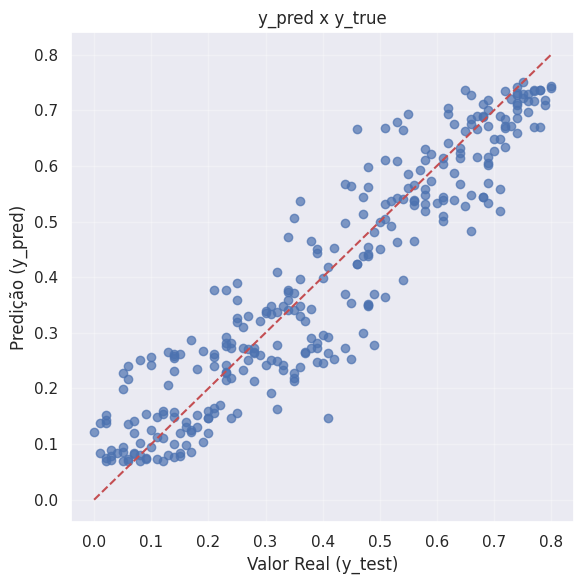

In [104]:
best_params_rf = study_rf.best_params

final_rf_model = RandomForestRegressor(**best_params_rf, 
                                     random_state=42, 
                                     n_jobs=-1)

final_rf_model.fit(X_train, y_train)

y_pred = final_rf_model.predict(X_test)

# (Opcional) Calcular o RMSE final para confirmar
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRMSE Final no Teste: {final_rmse:.4f}")
print(f"(Melhor RMSE do Optuna: {study_rf.best_value:.4f})")
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)

# gráfico y_pred x y_true
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

y_pred = final_rf_model.predict(selected_features_test)
RandomForest_pred = write_csv_file(y_pred)
RandomForest_pred

,CPMG,%
0,CPMG_000.csv,0.155905
1,CPMG_001.csv,0.714628
2,CPMG_002.csv,0.105922
3,CPMG_003.csv,0.156550
4,CPMG_004.csv,0.066937
...,...,...
995,CPMG_995.csv,0.110992
996,CPMG_996.csv,0.714566
997,CPMG_997.csv,0.106472
998,CPMG_998.csv,0.113649


### Pipeline completo predição

Para inferir a saturação do conjunto de teste (submissão):

-  Converter para o formato longo
- Extrair as mesmas características do TSFresh
- Selecionar as mesmas colunas de características (o modelo espera a mesma estrutura)
- Fazer a previsão com seu regressor

## TSFresh + Smoothing

In [108]:
### raw_data

dataset_path = 'data_train_post_n_smoothing.csv'
df = pd.read_csv(dataset_path, sep="\t").iloc[:, list(range(700)) + [-1]]
df.shape

test = pd.read_csv('data_test_post_n_smoothing.csv', sep="\t").iloc[:, list(range(700))]
print(df.shape , test.shape)

(1000, 701) (1000, 700)


In [111]:
X_2 = df.iloc[:, :700]
y = df['y']

# converter wide -> long format (TSFresh input)
df_long_2 = X_2.copy()
df_long_2['id'] = df_long_2.index

df_long_2 = df_long_2.melt(
    id_vars='id',
    var_name='time',
    value_name='value'
)

df_long_2

extracted_features_2 = extract_features(
    df_long_2,
    column_id="id",
    column_sort="time",
    default_fc_parameters=ComprehensiveFCParameters(),  # or EfficientFCParameters()
    impute_function=None
)

extracted_features_2 = impute(extracted_features_2)

selected_features_2 = select_features(extracted_features_2, y)

Feature Extraction: 100%|██████████| 334/334 [00:34<00:00,  9.74it/s]
/opt/venvs/torch/lib/python3.10/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning:

The columns ['value__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.



In [112]:
## test features

X_submissão = test

# converter wide -> long format (TSFresh input)
df_long_test = X_submissão.copy()
df_long_test['id'] = df_long_test.index

df_long_test = df_long_test.melt(
    id_vars='id',
    var_name='time',
    value_name='value'
)

extracted_features_test = extract_features(
    df_long_test,
    column_id="id",
    column_sort="time",
    default_fc_parameters=ComprehensiveFCParameters(),  # or EfficientFCParameters()
    impute_function=None
)

extracted_features_test = impute(extracted_features_test)
selected_features_test = extracted_features_test.loc[:, selected_features_2.columns]

Feature Extraction: 100%|██████████| 334/334 [00:33<00:00,  9.92it/s]
/opt/venvs/torch/lib/python3.10/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning:

The columns ['value__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.



In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    selected_features_2, y, test_size=0.3, random_state=42
)

### função objetivo
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 1500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.01, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 22),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse  # Optuna vai minimizar isso

# Rodar o estudo
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Melhores parâmetros:", study.best_params)
print("Melhor RMSE:", study.best_value)

[I 2025-11-12 19:41:11,265] A new study created in memory with name: no-name-fcbdacda-cd28-4723-ae7f-941b0f566a11
Best trial: 0. Best value: 0.138945:   2%|▏         | 1/50 [00:14<11:56, 14.62s/it]

[I 2025-11-12 19:41:25,882] Trial 0 finished with value: 0.13894477513659392 and parameters: {'n_estimators': 2432, 'learning_rate': 0.0017514653540141659, 'max_depth': 3, 'subsample': 0.8320266786616495, 'colsample_bytree': 0.3049379341278253, 'min_child_weight': 7, 'gamma': 4.853033989478231}. Best is trial 0 with value: 0.13894477513659392.


Best trial: 0. Best value: 0.138945:   4%|▍         | 2/50 [00:31<12:35, 15.73s/it]

[I 2025-11-12 19:41:42,393] Trial 1 finished with value: 0.18060495156207843 and parameters: {'n_estimators': 1667, 'learning_rate': 0.00022809202082524233, 'max_depth': 6, 'subsample': 0.8879203647560595, 'colsample_bytree': 0.7344961583044278, 'min_child_weight': 9, 'gamma': 2.552618384289816}. Best is trial 0 with value: 0.13894477513659392.


Best trial: 2. Best value: 0.112346:   6%|▌         | 3/50 [00:45<11:48, 15.08s/it]

...

[I 2025-11-12 19:49:19,824] Trial 47 finished with value: 0.12630537811538264 and parameters: {'n_estimators': 2291, 'learning_rate': 0.0014725290520689114, 'max_depth': 18, 'subsample': 0.9187998463764525, 'colsample_bytree': 0.6304978114849457, 'min_child_weight': 10, 'gamma': 3.6623137680373405}. Best is trial 21 with value: 0.08615558029313532.


Best trial: 21. Best value: 0.0861556:  98%|█████████▊| 49/50 [08:13<00:05,  5.99s/it]

[I 2025-11-12 19:49:24,919] Trial 48 finished with value: 0.09462680823584124 and parameters: {'n_estimators': 2699, 'learning_rate': 0.006992047629285277, 'max_depth': 1, 'subsample': 0.801642960588472, 'colsample_bytree': 0.5444956997359206, 'min_child_weight': 6, 'gamma': 0.748701731938052}. Best is trial 21 with value: 0.08615558029313532.


Best trial: 21. Best value: 0.0861556: 100%|██████████| 50/50 [08:20<00:00, 10.01s/it]

[I 2025-11-12 19:49:31,855] Trial 49 finished with value: 0.08643634833006138 and parameters: {'n_estimators': 2890, 'learning_rate': 0.004102107232469898, 'max_depth': 17, 'subsample': 0.7675775663049097, 'colsample_bytree': 0.683102732695634, 'min_child_weight': 9, 'gamma': 0.14503922331323477}. Best is trial 21 with value: 0.08615558029313532.
Melhores parâmetros: {'n_estimators': 2636, 'learning_rate': 0.0031459968658544384, 'max_depth': 16, 'subsample': 0.7446672673520635, 'colsample_bytree': 0.860870123276003, 'min_child_weight': 8, 'gamma': 0.12895851879039644}
Melhor RMSE: 0.08615558029313532


RMSE final: 0.08615558029313532


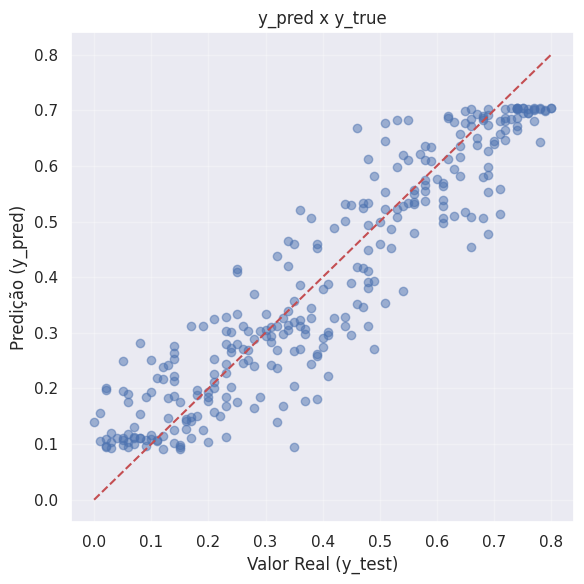

In [114]:
best_params_XGBoost = study.best_params

model = XGBRegressor(**best_params_XGBoost)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE final:", rmse)
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)

# gráfico y_pred x y_true
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predição (y_pred)")
plt.title("y_pred x y_true")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [115]:
### Arquivo da submissão
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

y_pred = model.predict(selected_features_test)
XGBoost_raw_data = write_csv_file(y_pred)
XGBoost_raw_data
y_pred

array([0.31980562, 0.7019158 , 0.15138018, 0.34141955, 0.10540795,
       0.1438494 , 0.33097163, 0.60002494, 0.30080083, 0.43784007,
       0.5430291 , 0.4709991 , 0.14711961, 0.30545866, 0.23733358,
       0.69623613, 0.30071437, 0.22029182, 0.19709936, 0.70155036,
       0.15974596, 0.39690062, 0.48795784, 0.50985974, 0.5111359 ,
       0.51925987, 0.17207779, 0.21624233, 0.50582004, 0.13759837,
       0.7019158 , 0.09703047, 0.09828024, 0.17115766, 0.6703491 ,
       0.40244782, 0.6642551 , 0.41159755, 0.09653586, 0.70206344,
       0.2634676 , 0.2980962 , 0.66749465, 0.10085513, 0.2838986 ,
       0.2665019 , 0.16940928, 0.29469472, 0.2953303 , 0.51087147,
       0.54646826, 0.12213053, 0.15960604, 0.09740666, 0.2137121 ,
       0.67708814, 0.25877377, 0.65187144, 0.31216317, 0.7009828 ,
       0.6961772 , 0.17520297, 0.28789067, 0.10994722, 0.11328504,
       0.6953891 , 0.27158463, 0.43196237, 0.27435195, 0.53953373,
       0.553909  , 0.26407716, 0.35087356, 0.2304475 , 0.16226

Gráfico de evolução dos hiperparâmetros salvo como 'evolucao_hiperparametros.png'


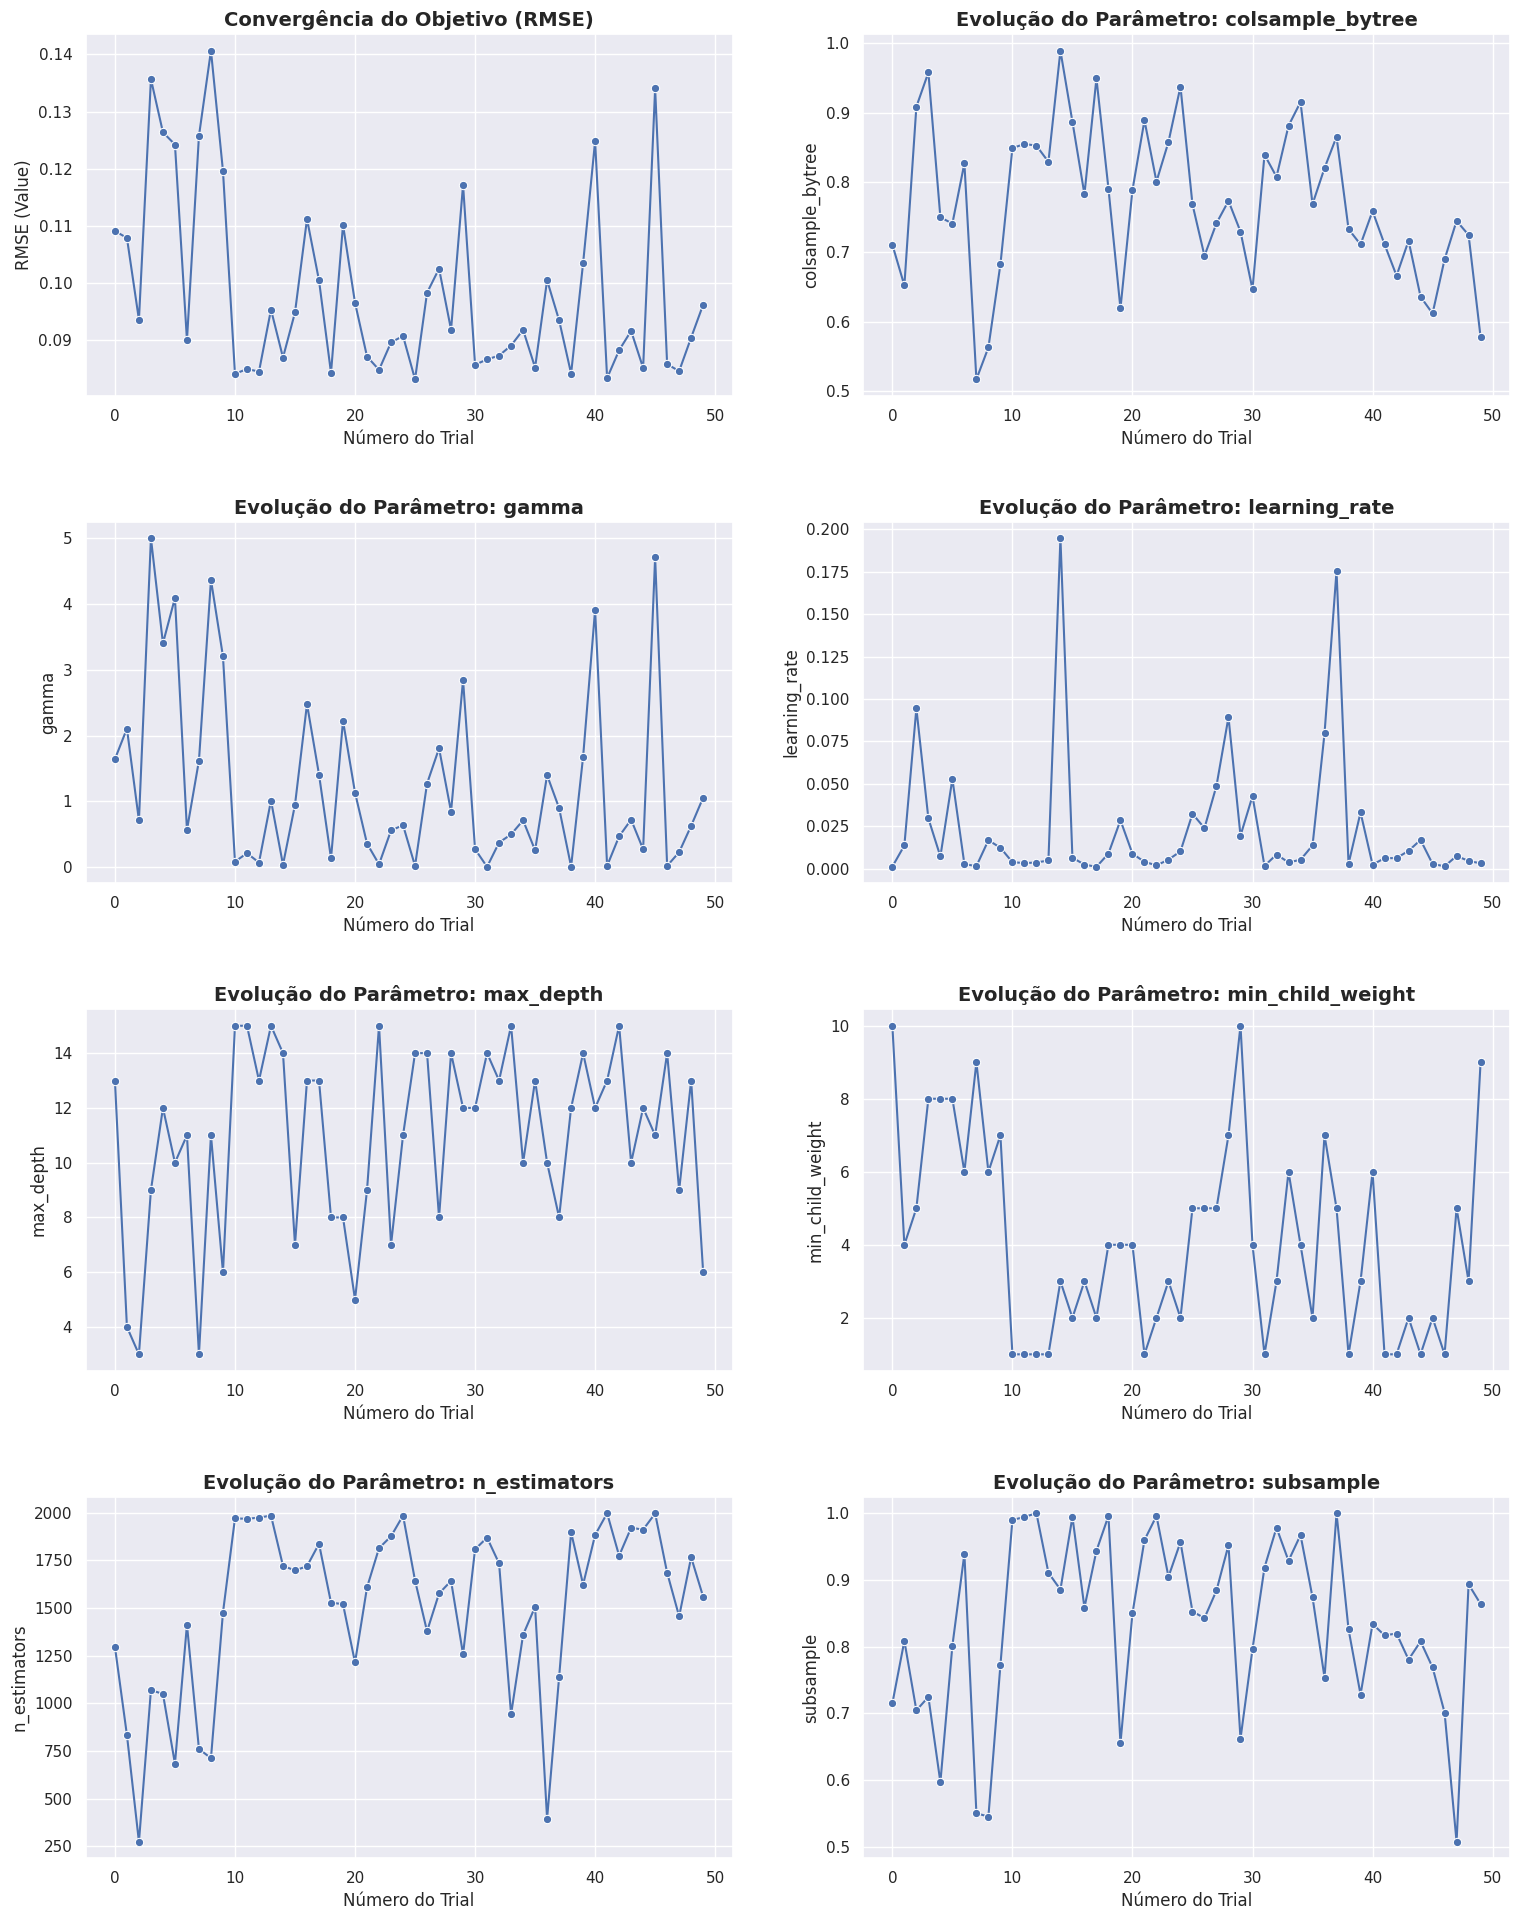

In [116]:
sns.set_theme(style="darkgrid", palette="deep")

# 2. Listar todas as colunas que queremos plotar
columns_to_plot = [
    'value', 
    'params_colsample_bytree', 
    'params_gamma', 
    'params_learning_rate', 
    'params_max_depth', 
    'params_min_child_weight', 
    'params_n_estimators', 
    'params_subsample'
]

# 3. Criar a grade de subplots (4 linhas, 2 colunas)
fig, axes = plt.subplots(4, 2, figsize=(16, 20)) # (Largura, Altura)
# Achatar o array de eixos para facilitar a iteração
axes = axes.flatten()

# 4. Iterar e criar cada plot
for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    
    # Usar sns.lineplot para um visual melhor
    sns.lineplot(
        data=df_trials,
        x='number',
        y=col,
        ax=ax,
        marker='o', # Adicionar marcadores como no original
        label=col
    )
    
    # 5. Definir títulos e labels "limpos"
    if col == 'value':
        title = "Convergência do Objetivo (RMSE)"
        ylabel = "RMSE (Value)"
    else:
        # Remove 'params_' para um título mais limpo
        param_name = col.replace('params_', '')
        title = f"Evolução do Parâmetro: {param_name}"
        ylabel = param_name
        
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Número do Trial", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Remover legenda de cada subplot (não é necessária)
    ax.get_legend().remove()

# 6. Ajustar layout para evitar sobreposição
plt.tight_layout(pad=3.0) # Adicionar um pouco de preenchimento

# 7. Salvar a figura
plot_filename = "evolucao_hiperparametros.png"
plt.savefig(plot_filename)

print(f"Gráfico de evolução dos hiperparâmetros salvo como '{plot_filename}'")